# Exploratory Data Analysis

In this section, the cleaned master dataset is explored to understand state-level EV charging investment potential. The analysis focuses on EV demand, EV growth momentum, charging infrastructure supply, economic strength, and power readiness.

Before creating visualizations, the dataset is checked for structure, missing values, duplicate states, and data consistency. This ensures that the final EDA and investment scoring are based on a clean and reliable state-level dataset.


In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
master_df = pd.read_csv("../data/cleaned/master_ev_investment_dataset_updated.csv")

In [3]:
master_df.shape

(14, 29)

In [4]:
master_df.columns

Index(['State', 'Latest_EV_Year', 'Annual_EV_Registrations_2025_26',
       'Cumulative_EV_Registrations_2025_26', 'EV_CAGR_2020_21_to_2025_26',
       'EV_Share_2025_26', 'Charging_Station_Count', 'Total_Connectors',
       'Fast_Charger_Count', 'Avg_Charger_Rating', 'District_Count',
       'City_Count', 'Private_Charger_Rows', 'Govt_Charger_Rows',
       'Connectors_per_Station', 'Fast_Charger_Share',
       'Cumulative_EVs_per_Charging_Station', 'Cumulative_EVs_per_Connector',
       'Annual_EVs_2025_26_per_Charging_Station',
       'Annual_EVs_2025_26_per_Connector', 'GSDP_2023_24', 'PC_NSDP_2023_24',
       'Period', 'Date', 'Peak_Demand', 'Peak_Met', 'Peak_Deficit',
       'Peak_Deficit_Percentage', 'Power_Readiness_Score'],
      dtype='object')

In [5]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   State                                    14 non-null     object 
 1   Latest_EV_Year                           14 non-null     object 
 2   Annual_EV_Registrations_2025_26          14 non-null     float64
 3   Cumulative_EV_Registrations_2025_26      14 non-null     float64
 4   EV_CAGR_2020_21_to_2025_26               14 non-null     float64
 5   EV_Share_2025_26                         14 non-null     float64
 6   Charging_Station_Count                   14 non-null     int64  
 7   Total_Connectors                         14 non-null     int64  
 8   Fast_Charger_Count                       14 non-null     int64  
 9   Avg_Charger_Rating                       14 non-null     float64
 10  District_Count                           14 non-null

In [6]:
master_df.isnull().sum()

State                                      0
Latest_EV_Year                             0
Annual_EV_Registrations_2025_26            0
Cumulative_EV_Registrations_2025_26        0
EV_CAGR_2020_21_to_2025_26                 0
EV_Share_2025_26                           0
Charging_Station_Count                     0
Total_Connectors                           0
Fast_Charger_Count                         0
Avg_Charger_Rating                         0
District_Count                             0
City_Count                                 0
Private_Charger_Rows                       0
Govt_Charger_Rows                          0
Connectors_per_Station                     0
Fast_Charger_Share                         0
Cumulative_EVs_per_Charging_Station        0
Cumulative_EVs_per_Connector               0
Annual_EVs_2025_26_per_Charging_Station    0
Annual_EVs_2025_26_per_Connector           0
GSDP_2023_24                               0
PC_NSDP_2023_24                            0
Period    

In [7]:
master_df["State"].nunique()

14

In [8]:
master_df["State"].value_counts()

State
Andhra Pradesh    1
Delhi             1
Gujarat           1
Haryana           1
Karnataka         1
Kerala            1
Madhya Pradesh    1
Maharashtra       1
Punjab            1
Rajasthan         1
Tamil Nadu        1
Telangana         1
Uttar Pradesh     1
West Bengal       1
Name: count, dtype: int64

The cleaned master dataset contains one row per selected state/UT and combines EV demand, EV growth, charging infrastructure, economic strength, and power readiness variables. Initial validation confirms that the dataset is structured at the state level and is ready for exploratory analysis.


## 1. EV Demand by State

The first step in the exploratory analysis is to compare current EV demand across the selected states/UTs. EV registrations for 2025 are used as the main demand indicator.

A state with higher EV registrations represents a larger existing EV market. This is important for charging infrastructure investment because higher EV adoption generally creates stronger demand for public charging stations and connectors.


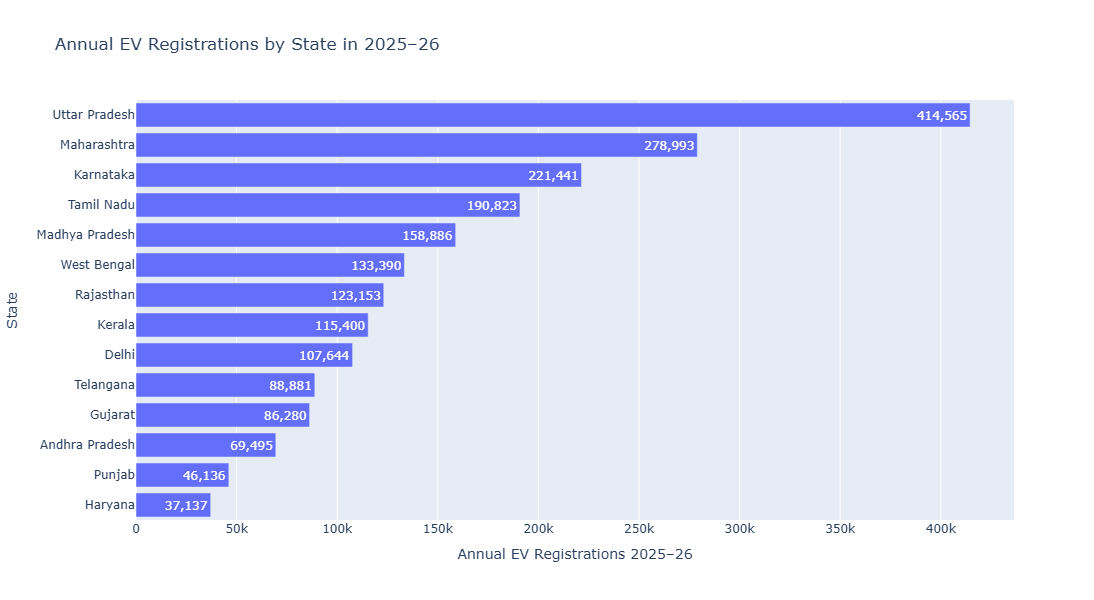

In [9]:
annual_ev_demand = master_df.sort_values(
    "Annual_EV_Registrations_2025_26",
    ascending=False
)

fig = px.bar(
    annual_ev_demand,
    x="Annual_EV_Registrations_2025_26",
    y="State",
    orientation="h",
    title="Annual EV Registrations by State in 2025–26",
    labels={
        "Annual_EV_Registrations_2025_26": "Annual EV Registrations 2025–26",
        "State": "State"
    },
    text="Annual_EV_Registrations_2025_26"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Annual EV Registrations by State

Uttar Pradesh recorded the highest annual EV registrations in 2025–26, with more than 4.14 lakh new EV registrations. Maharashtra, Karnataka, and Tamil Nadu also show strong annual EV demand, indicating active EV adoption in these states.

However, annual registrations only represent the latest yearly demand. For charging infrastructure pressure, cumulative EV registrations are more useful because public charging stations serve the total EV base, not only vehicles registered in one year.

## 2. Cumulative EV Market Size by State

After comparing annual EV registrations, the next step is to examine cumulative EV registrations up to 2025–26. This metric represents the accumulated EV market base using the available year-wise EV registration data.

Cumulative EV registrations are important because charging infrastructure serves the total EV base in a state, not only the vehicles registered during the latest year. Therefore, this metric is more suitable for understanding charging infrastructure pressure and long-term EV market size.


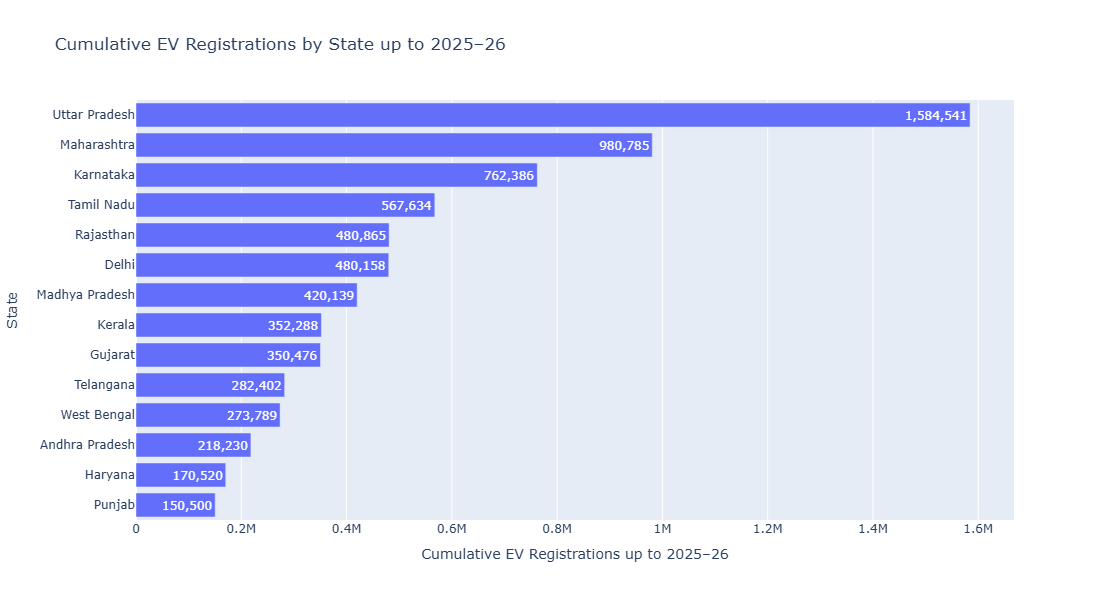

In [10]:
cumulative_ev_market = master_df.sort_values(
    "Cumulative_EV_Registrations_2025_26",
    ascending=False
)

fig = px.bar(
    cumulative_ev_market,
    x="Cumulative_EV_Registrations_2025_26",
    y="State",
    orientation="h",
    title="Cumulative EV Registrations by State up to 2025–26",
    labels={
        "Cumulative_EV_Registrations_2025_26": "Cumulative EV Registrations up to 2025–26",
        "State": "State"
    },
    text="Cumulative_EV_Registrations_2025_26"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Cumulative EV Registrations by State

Uttar Pradesh has the largest cumulative EV base among the selected states, with more than 15.8 lakh cumulative EV registrations up to 2025–26. Maharashtra and Karnataka follow with large cumulative EV markets, showing that these states have already developed sizeable EV ecosystems.

Delhi and Rajasthan have similar cumulative EV registrations, even though their economic and infrastructure profiles are different. This suggests that EV market size should be compared with charging supply, income levels, and power readiness before making investment conclusions.

## 3. EV Growth Momentum by State

EV CAGR from 2020–21 to 2025–26 is used to compare the growth momentum of EV registrations across states. While annual and cumulative EV registrations show current market size, CAGR helps identify states where EV adoption is expanding rapidly over time.

This is useful for investment analysis because some states may not currently have the largest EV base, but strong growth momentum may indicate future charging infrastructure demand.


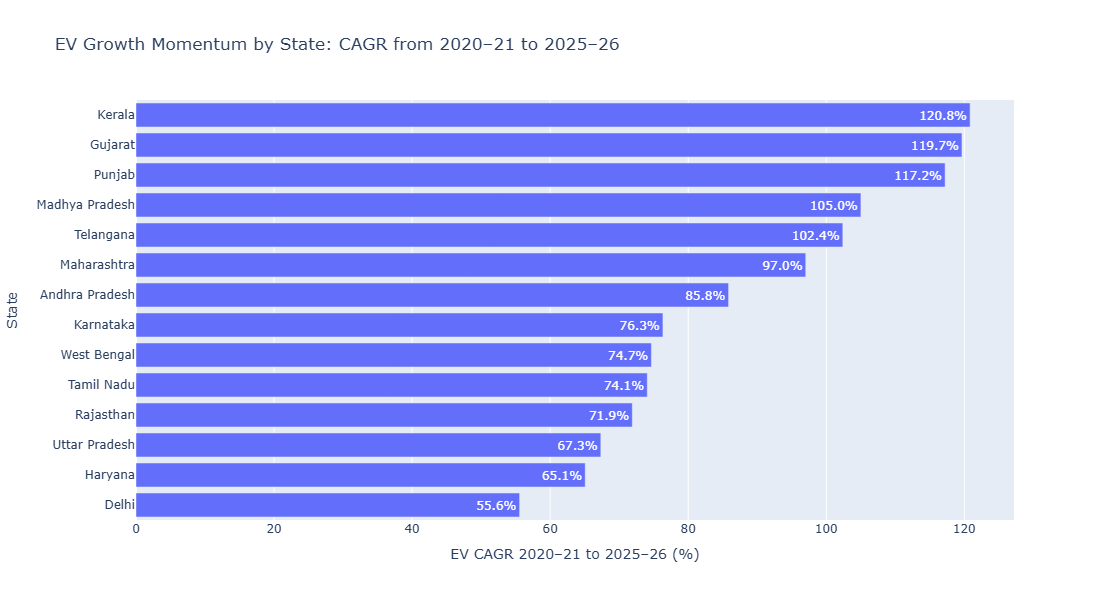

In [11]:
ev_growth = master_df.sort_values(
    "EV_CAGR_2020_21_to_2025_26",
    ascending=False
)

fig = px.bar(
    ev_growth,
    x="EV_CAGR_2020_21_to_2025_26",
    y="State",
    orientation="h",
    title="EV Growth Momentum by State: CAGR from 2020–21 to 2025–26",
    labels={
        "EV_CAGR_2020_21_to_2025_26": "EV CAGR 2020–21 to 2025–26 (%)",
        "State": "State"
    },
    text="EV_CAGR_2020_21_to_2025_26"
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: EV Growth Momentum

Kerala, Gujarat, and Punjab show the highest EV CAGR between 2020–21 and 2025–26. This indicates strong growth momentum, even though some of these states do not have the largest cumulative EV base.

Delhi has the lowest CAGR among the selected states, but this does not mean weak EV adoption. Delhi already has a high EV share, so its slower growth rate may reflect a more mature EV market compared to states growing rapidly from a smaller base.

The CAGR values should be interpreted as growth momentum, not as the only measure of market strength.

## 4. EV Adoption Intensity by State

EV share in total vehicle registrations for 2025–26 is used to compare EV adoption intensity across states. Unlike total EV registrations, this metric shows how strongly EVs are penetrating the overall vehicle market in each state.

This is important because a large state may have high EV registrations simply due to its population and vehicle market size, while a smaller state may show stronger EV adoption intensity through a higher EV share.


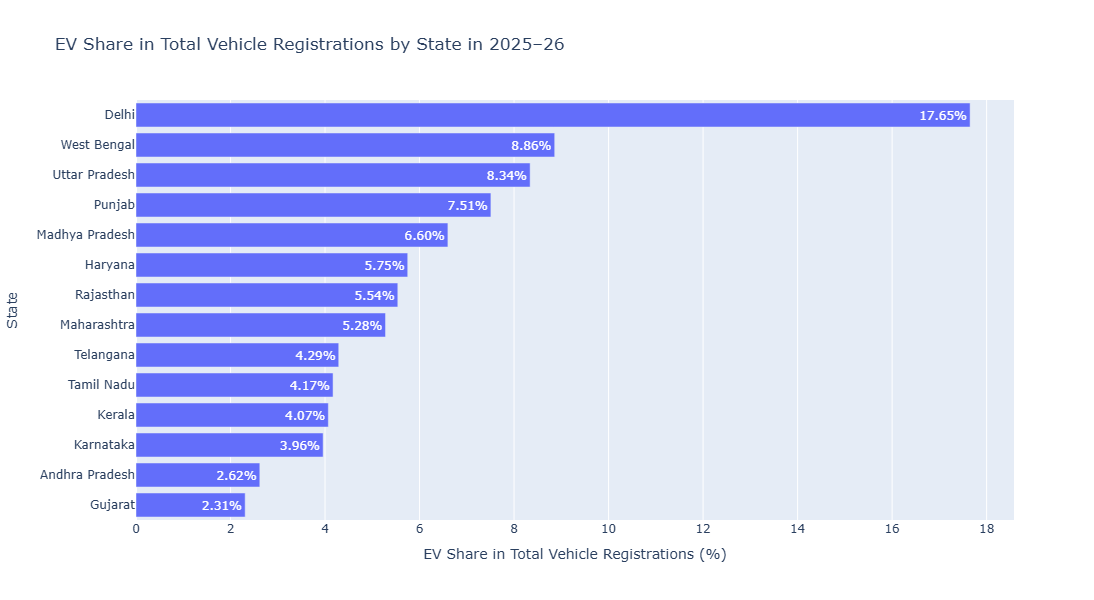

In [12]:
ev_share_plot = master_df.sort_values(
    "EV_Share_2025_26",
    ascending=False
)

fig = px.bar(
    ev_share_plot,
    x="EV_Share_2025_26",
    y="State",
    orientation="h",
    title="EV Share in Total Vehicle Registrations by State in 2025–26",
    labels={
        "EV_Share_2025_26": "EV Share in Total Vehicle Registrations (%)",
        "State": "State"
    },
    text="EV_Share_2025_26"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: EV Share in Total Vehicle Registrations

Delhi has the highest EV share in total vehicle registrations at 17.65%, making it the strongest state/UT in terms of EV adoption intensity. West Bengal, Uttar Pradesh, and Punjab also show relatively high EV shares.

Gujarat and Andhra Pradesh have lower EV shares despite showing different levels of EV growth and economic strength. This indicates that EV adoption intensity does not depend only on state income or economic size. Policy support, urban mobility patterns, vehicle category mix, and consumer adoption behavior may also influence EV share.

## 5. Charging Station Supply by State

After analyzing EV demand and EV adoption, the next step is to compare the current public charging station supply across states. Charging station count is used as a basic infrastructure indicator.

States with higher charging station counts have stronger existing charging infrastructure. However, this does not always mean they are the best investment markets. A state with fewer chargers but high EV demand may show a larger charging gap and stronger expansion opportunity.


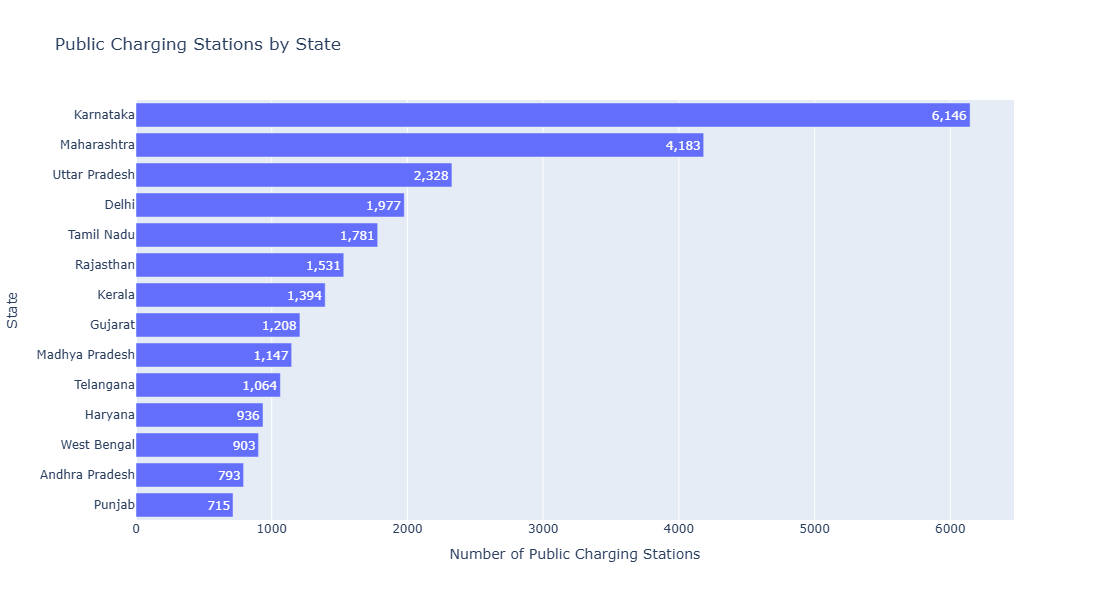

In [13]:
charging_supply = master_df.sort_values(
    "Charging_Station_Count",
    ascending=False
)

fig = px.bar(
    charging_supply,
    x="Charging_Station_Count",
    y="State",
    orientation="h",
    title="Public Charging Stations by State",
    labels={
        "Charging_Station_Count": "Number of Public Charging Stations",
        "State": "State"
    },
    text="Charging_Station_Count"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Public Charging Stations by State

Karnataka has the highest number of public charging stations, followed by Maharashtra. These two states have much stronger charging station availability compared to the remaining states.

Uttar Pradesh has the highest annual and cumulative EV registrations but ranks third in charging station count. This creates an early signal that charging infrastructure may not be keeping pace with EV demand in Uttar Pradesh.

## 6. Total Charging Connectors by State

Charging station count shows the number of charging locations, but total connectors provide a better measure of actual charging capacity. A state may have fewer stations but more connectors per station, which can improve its ability to serve EV users.

This chart compares the total number of public charging connectors across states and helps identify which states have stronger charging capacity.


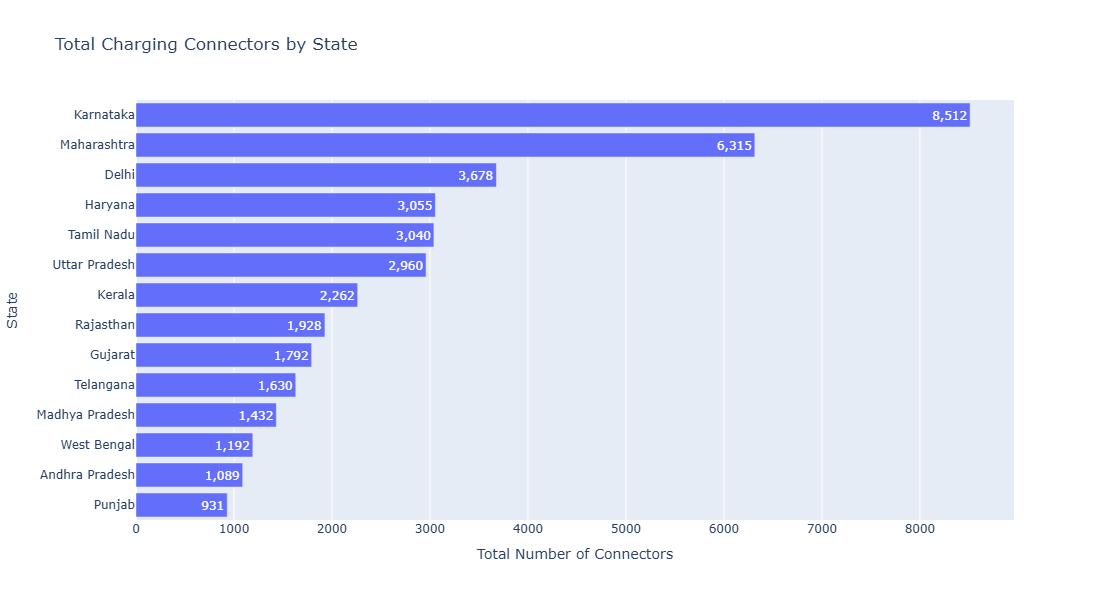

In [14]:
connector_supply = master_df.sort_values(
    "Total_Connectors",
    ascending=False
)

fig = px.bar(
    connector_supply,
    x="Total_Connectors",
    y="State",
    orientation="h",
    title="Total Charging Connectors by State",
    labels={
        "Total_Connectors": "Total Number of Connectors",
        "State": "State"
    },
    text="Total_Connectors"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Total Charging Connectors by State

Karnataka and Maharashtra also lead in total charging connectors, showing that they have stronger charging capacity in addition to more charging stations. Delhi, Haryana, Tamil Nadu, and Uttar Pradesh form the next group of states in terms of connector availability.

Haryana is interesting because it has relatively low EV registrations but a high number of connectors. This suggests that Haryana may be better supplied relative to its current EV base.

## 7. Fast Charger Share by State

After comparing the number of charging stations and total connectors, the next step is to examine charging infrastructure quality. Fast charger share is used to understand how much of the charging infrastructure is capable of supporting faster charging.

This is important because charging infrastructure quality matters along with quantity. A state may have many charging stations, but if the share of fast chargers is low, users may still face longer charging times and weaker charging convenience.


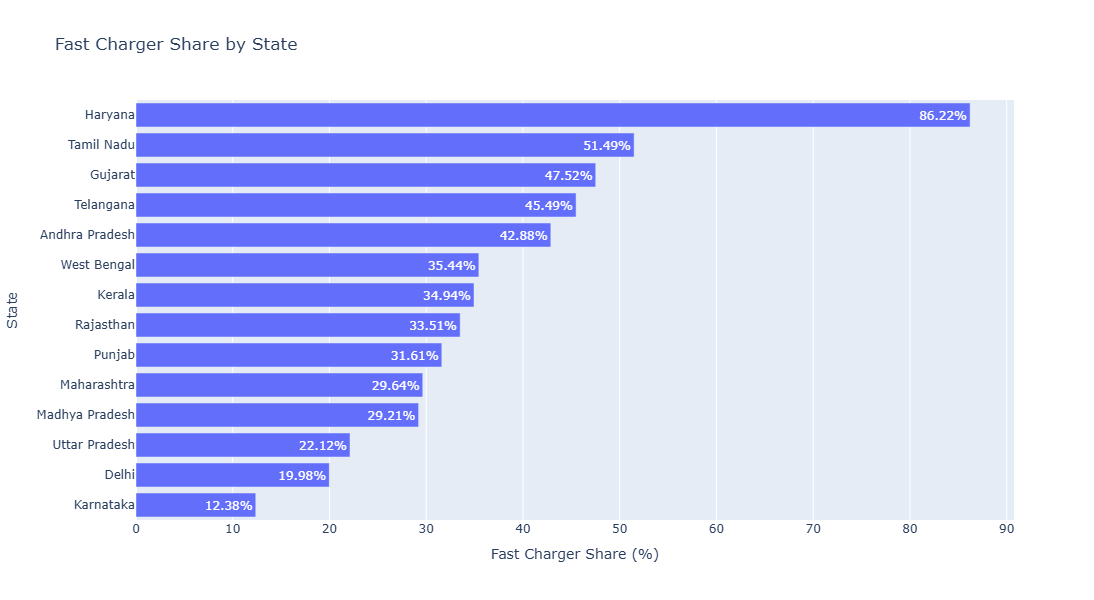

In [15]:
fast_charger_share_plot = master_df.sort_values(
    "Fast_Charger_Share",
    ascending=False
)

fig = px.bar(
    fast_charger_share_plot,
    x="Fast_Charger_Share",
    y="State",
    orientation="h",
    title="Fast Charger Share by State",
    labels={
        "Fast_Charger_Share": "Fast Charger Share (%)",
        "State": "State"
    },
    text="Fast_Charger_Share"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Fast Charger Share by State

Haryana has the highest fast charger share, indicating strong charging quality relative to its total charging infrastructure. Tamil Nadu, Gujarat, Telangana, and Andhra Pradesh also show relatively strong fast charger shares.

Karnataka has the highest number of charging stations and connectors, but one of the lowest fast charger shares. This shows that infrastructure quantity and infrastructure quality are not always the same. A state can have many chargers but still have a lower share of fast chargers.

## 8. Charging Gap: Cumulative EVs per Connector

Cumulative EVs per connector is used to measure charging infrastructure pressure across states. This metric compares the estimated EV market base with the number of available public charging connectors.

A higher value means that each connector is serving a larger number of EVs, which may indicate a stronger charging infrastructure gap. Such states may offer higher investment opportunity because EV adoption has grown faster than charging connector availability.


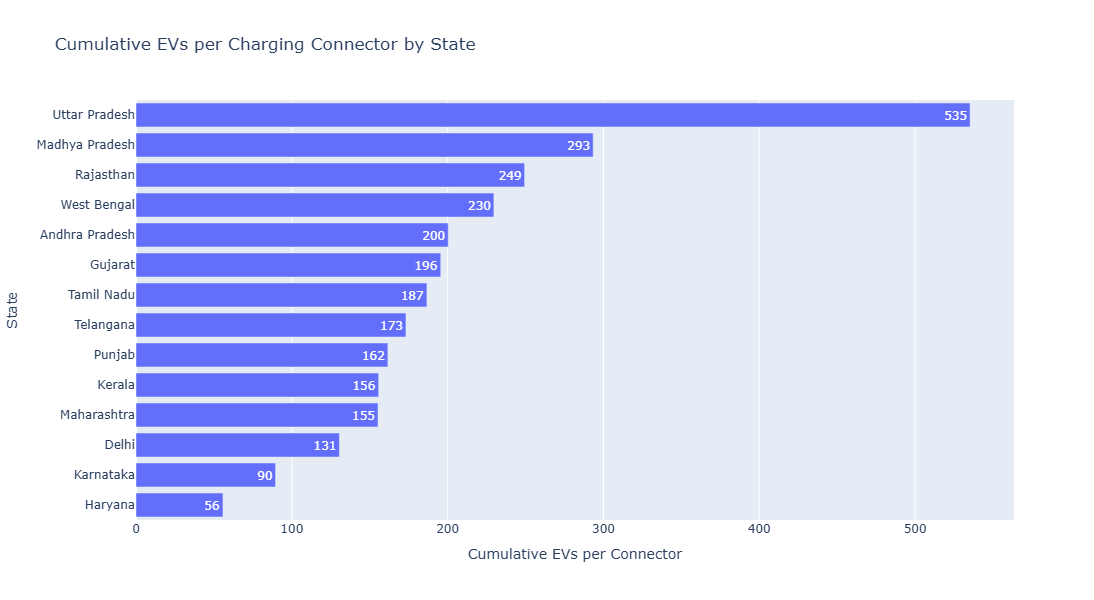

In [16]:
charging_gap_connector = master_df.sort_values(
    "Cumulative_EVs_per_Connector",
    ascending=False
)

fig = px.bar(
    charging_gap_connector,
    x="Cumulative_EVs_per_Connector",
    y="State",
    orientation="h",
    title="Cumulative EVs per Charging Connector by State",
    labels={
        "Cumulative_EVs_per_Connector": "Cumulative EVs per Connector",
        "State": "State"
    },
    text="Cumulative_EVs_per_Connector"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Cumulative EVs per Connector

Uttar Pradesh has the highest cumulative EVs per connector, showing the strongest charging pressure among the selected states. This means that each public connector in Uttar Pradesh is serving a much larger EV base compared to other states.

Madhya Pradesh, Rajasthan, West Bengal, Andhra Pradesh, and Gujarat also show higher EVs per connector. These states may have stronger charging infrastructure gaps compared to better-supplied states such as Haryana and Karnataka.

## 9. Charging Gap: Cumulative EVs per Charging Station

Cumulative EVs per charging station compares the estimated EV market base with the number of public charging stations available in each state.

This metric helps identify states where the charging station network may be under pressure. A higher value indicates that each charging station is serving a larger EV base, which may point toward stronger need for charging infrastructure expansion.


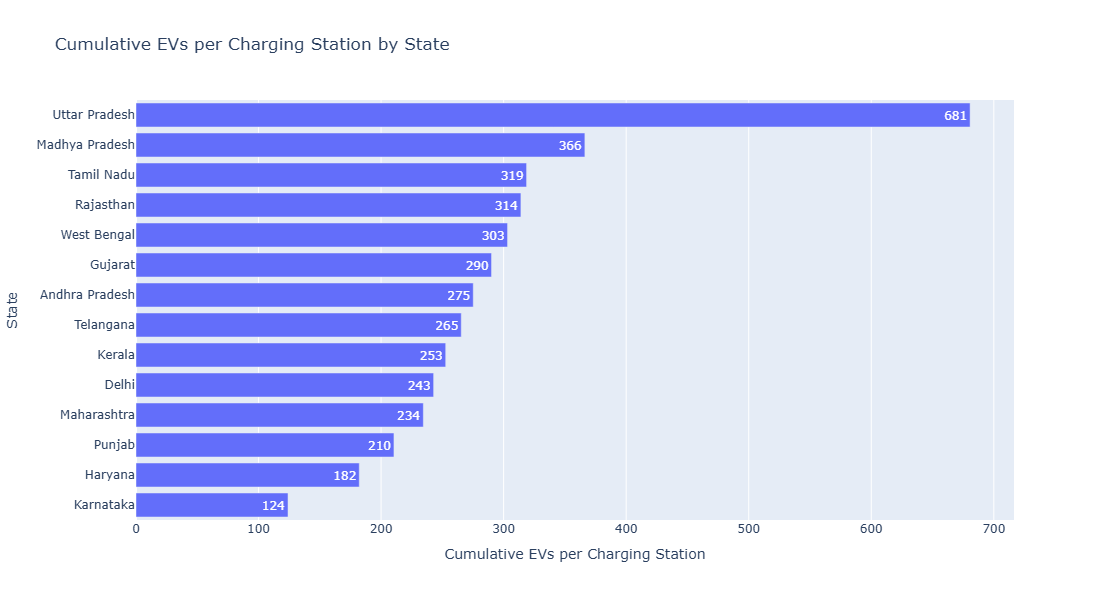

In [17]:
charging_gap_station = master_df.sort_values(
    "Cumulative_EVs_per_Charging_Station",
    ascending=False
)

fig = px.bar(
    charging_gap_station,
    x="Cumulative_EVs_per_Charging_Station",
    y="State",
    orientation="h",
    title="Cumulative EVs per Charging Station by State",
    labels={
        "Cumulative_EVs_per_Charging_Station": "Cumulative EVs per Charging Station",
        "State": "State"
    },
    text="Cumulative_EVs_per_Charging_Station"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Cumulative EVs per Charging Station

Uttar Pradesh again shows the highest cumulative EVs per charging station, confirming that it faces strong charging infrastructure pressure at both station and connector levels.

Madhya Pradesh, Tamil Nadu, Rajasthan, and West Bengal also show relatively high EVs per station. This suggests that these states may require further charging station expansion if EV adoption continues to grow.

Karnataka and Haryana show lower pressure, indicating that their existing charging station network is stronger relative to their EV base.

## 10. EV Market Size vs Charging Connector Supply

This scatter plot compares cumulative EV registrations with total charging connectors across states. The purpose is to understand whether states with larger EV markets also have proportionally stronger charging connector supply.

As the color moves toward a red hue, the pressure on charging infrastructure increases. Redder bubbles indicate higher EVs per connector, suggesting stronger charging pressure and a possible charging infrastructure expansion opportunity.



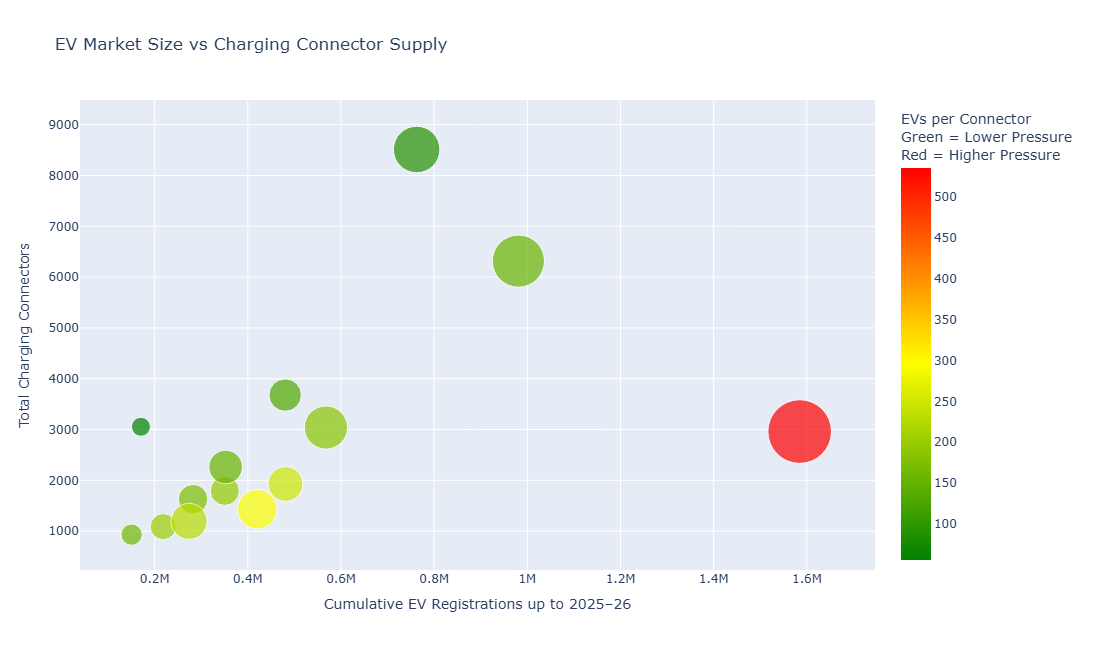

In [18]:
fig = px.scatter(
    master_df,
    x="Cumulative_EV_Registrations_2025_26",
    y="Total_Connectors",
    size="Annual_EV_Registrations_2025_26",
    color="Cumulative_EVs_per_Connector",
    hover_name="State",
    title="EV Market Size vs Charging Connector Supply",
    labels={
        "Cumulative_EV_Registrations_2025_26": "Cumulative EV Registrations up to 2025–26",
        "Total_Connectors": "Total Charging Connectors",
        "Annual_EV_Registrations_2025_26": "Annual EV Registrations 2025–26",
        "Cumulative_EVs_per_Connector": "Charging Pressure: EVs per Connector"
    },
    size_max=45,
    color_continuous_scale=[
        [0.0, "green"],
        [0.5, "yellow"],
        [1.0, "red"]
    ]
)

fig.update_layout(
    height=650,
    coloraxis_colorbar=dict(
        title="EVs per Connector<br>Green = Lower Pressure<br>Red = Higher Pressure"
    )
)

fig.show()

## Observation: EV Market Size vs Charging Connector Supply

The scatter plot shows that Uttar Pradesh has the largest cumulative EV market but comparatively lower connector supply, placing it in a high charging pressure zone. Its red bubble indicates that infrastructure pressure increases as the color moves toward red.

Karnataka and Maharashtra appear better balanced because they have both large EV markets and strong connector supply. Haryana appears relatively well supplied because it has a smaller EV base but a high number of connectors.

This chart is one of the strongest visuals in the project because it directly shows the demand-supply gap between EV market size and charging connector availability.

## 11. Annual EV Demand vs Charging Station Supply

This scatter plot compares annual EV registrations in 2025–26 with the number of public charging stations across states. The purpose is to understand whether current EV adoption activity is supported by enough charging station availability.

Bubble size represents cumulative EV registrations, while color represents annual EVs per charging station. As the color moves toward a red hue, the pressure on charging infrastructure increases. Redder bubbles indicate higher annual EV demand per charging station, suggesting stronger short-term charging pressure and possible infrastructure expansion opportunity.


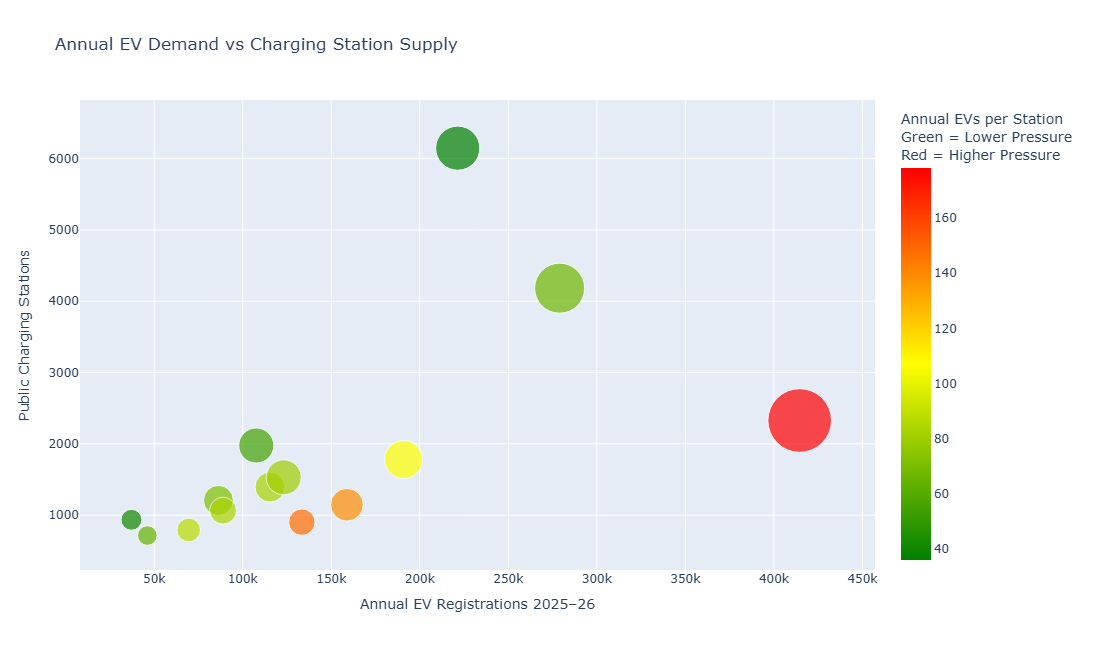

In [19]:
fig = px.scatter(
    master_df,
    x="Annual_EV_Registrations_2025_26",
    y="Charging_Station_Count",
    size="Cumulative_EV_Registrations_2025_26",
    color="Annual_EVs_2025_26_per_Charging_Station",
    hover_name="State",
    title="Annual EV Demand vs Charging Station Supply",
    labels={
        "Annual_EV_Registrations_2025_26": "Annual EV Registrations 2025–26",
        "Charging_Station_Count": "Public Charging Stations",
        "Cumulative_EV_Registrations_2025_26": "Cumulative EV Registrations up to 2025–26",
        "Annual_EVs_2025_26_per_Charging_Station": "Annual EVs per Charging Station"
    },
    size_max=45,
    color_continuous_scale=[
        [0.0, "green"],
        [0.5, "yellow"],
        [1.0, "red"]
    ]
)

fig.update_layout(
    height=650,
    coloraxis_colorbar=dict(
        title="Annual EVs per Station<br>Green = Lower Pressure<br>Red = Higher Pressure"
    )
)

fig.show()

## Observation: Annual EV Demand vs Charging Station Supply

Uttar Pradesh again stands out as the strongest short-term charging pressure case because it has the highest annual EV registrations but a comparatively lower charging station network. The red color shows that annual EV demand per charging station is high.

Karnataka and Maharashtra show stronger charging station availability relative to their annual EV demand. This suggests that they are more mature EV infrastructure markets, while Uttar Pradesh may represent a stronger expansion opportunity.

## 12. Economic Strength by State

GSDP at current prices for 2023–24 is used as an indicator of state-level economic strength. A higher GSDP suggests a larger economic base, stronger commercial activity, and potentially higher capacity to support EV charging infrastructure investment.

Economic strength is important because EV charging infrastructure expansion depends not only on EV demand, but also on the overall market size, business activity, and investment capacity of a state.


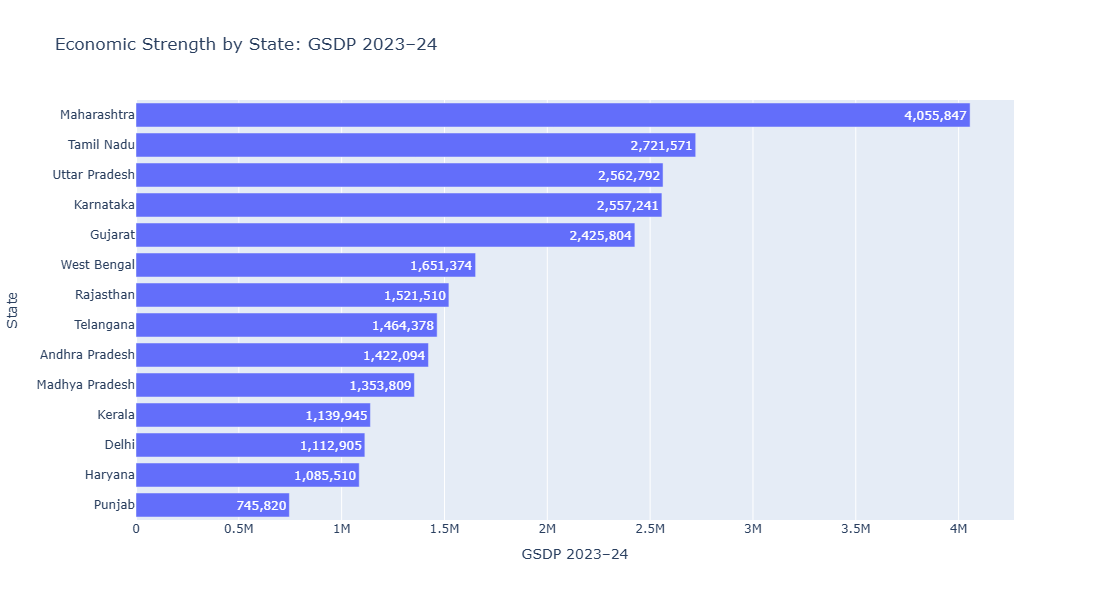

In [20]:
gsdp_plot = master_df.sort_values(
    "GSDP_2023_24",
    ascending=False
)

fig = px.bar(
    gsdp_plot,
    x="GSDP_2023_24",
    y="State",
    orientation="h",
    title="Economic Strength by State: GSDP 2023–24",
    labels={
        "GSDP_2023_24": "GSDP 2023–24",
        "State": "State"
    },
    text="GSDP_2023_24"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Economic Strength by State

Maharashtra has the highest GSDP among the selected states, followed by Tamil Nadu, Uttar Pradesh, Karnataka, and Gujarat. These states represent large economic markets and may have stronger capacity to support EV charging investment.

However, high GSDP alone does not guarantee the highest charging opportunity. For example, Uttar Pradesh has a large economy and the largest EV base, but also shows high charging pressure. This makes it especially important from an investment gap perspective.

## 13. Per-Capita Economic Strength by State

Per-capita NSDP at current prices for 2023–24 is used to compare economic strength at the individual level. While GSDP shows the total size of a state economy, per-capita NSDP helps understand income and affordability conditions.

This metric is important for EV charging investment because states with higher per-capita income may have stronger purchasing power, higher EV affordability, and better potential for private EV adoption.


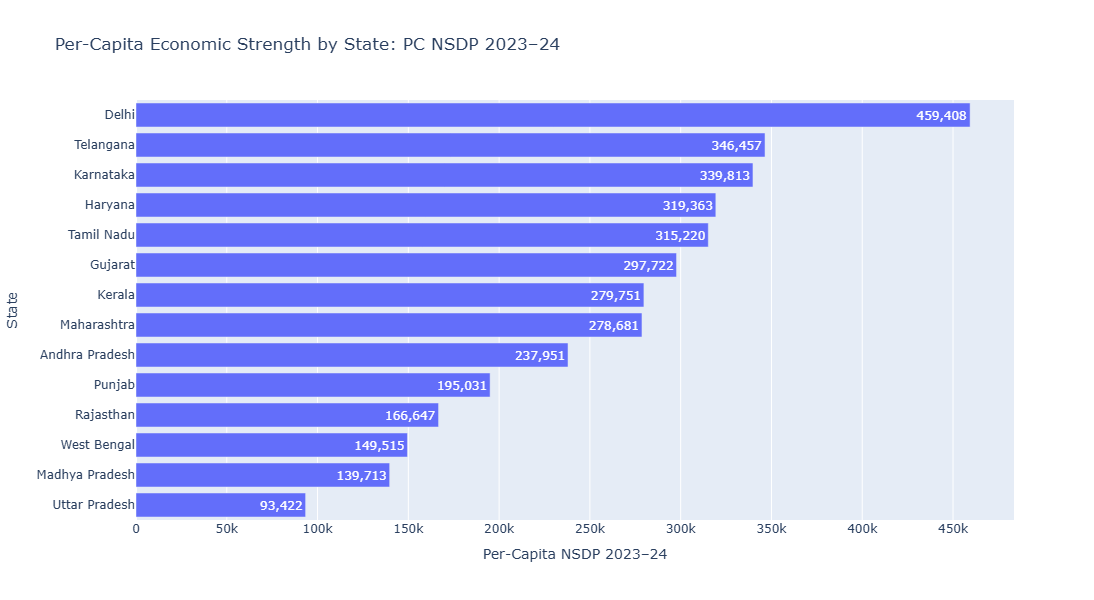

In [21]:
pc_nsdp_plot = master_df.sort_values(
    "PC_NSDP_2023_24",
    ascending=False
)

fig = px.bar(
    pc_nsdp_plot,
    x="PC_NSDP_2023_24",
    y="State",
    orientation="h",
    title="Per-Capita Economic Strength by State: PC NSDP 2023–24",
    labels={
        "PC_NSDP_2023_24": "Per-Capita NSDP 2023–24",
        "State": "State"
    },
    text="PC_NSDP_2023_24"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600
)

fig.show()

## Observation: Per-Capita Economic Strength by State

Delhi has the highest per-capita NSDP, followed by Telangana, Karnataka, Haryana, and Tamil Nadu. These states may have stronger individual purchasing power and better affordability conditions for EV adoption.

Uttar Pradesh has the lowest per-capita NSDP among the selected states, but still has the largest annual and cumulative EV registrations. This suggests that EV adoption in Uttar Pradesh may be driven more by market size and vehicle volume than by per-capita income alone.

## 14. EV Adoption Intensity vs Per-Capita Income

This scatter plot compares per-capita NSDP with EV share in total vehicle registrations. The purpose is to understand whether states with higher income levels also show stronger EV adoption intensity.

The x-axis represents per-capita economic strength, while the y-axis represents EV adoption intensity. Bubble size represents cumulative EV registrations, and color represents EV growth momentum. As the color moves toward green, EV growth momentum is stronger.

This chart helps identify whether EV adoption is mainly concentrated in richer states or whether some states are achieving strong EV adoption despite lower per-capita income.


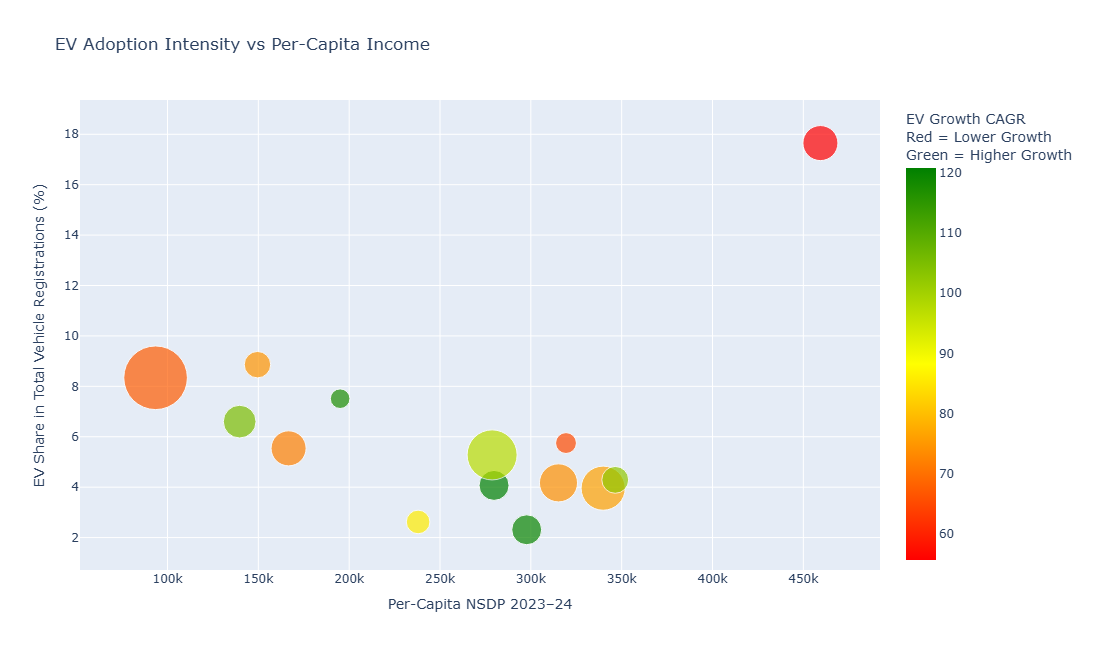

In [22]:
fig = px.scatter(
    master_df,
    x="PC_NSDP_2023_24",
    y="EV_Share_2025_26",
    size="Cumulative_EV_Registrations_2025_26",
    color="EV_CAGR_2020_21_to_2025_26",
    hover_name="State",
    title="EV Adoption Intensity vs Per-Capita Income",
    labels={
        "PC_NSDP_2023_24": "Per-Capita NSDP 2023–24",
        "EV_Share_2025_26": "EV Share in Total Vehicle Registrations (%)",
        "Cumulative_EV_Registrations_2025_26": "Cumulative EV Registrations up to 2025–26",
        "EV_CAGR_2020_21_to_2025_26": "EV CAGR 2020–21 to 2025–26 (%)"
    },
    size_max=45,
    color_continuous_scale=[
        [0.0, "red"],
        [0.5, "yellow"],
        [1.0, "green"]
    ]
)

fig.update_layout(
    height=650,
    coloraxis_colorbar=dict(
        title="EV Growth CAGR<br>Red = Lower Growth<br>Green = Higher Growth"
    )
)

fig.show()

## Observation: EV Adoption Intensity vs Per-Capita Income

Delhi stands out with both the highest per-capita income and the highest EV share, indicating a strong mature EV adoption profile. However, its EV growth momentum is lower, suggesting that it may already be a relatively mature EV market.

Uttar Pradesh has low per-capita income but high EV share and the largest EV base, making it an important mass-market EV adoption case. Gujarat has higher per-capita income and strong EV growth, but lower EV share, indicating future adoption potential rather than current adoption intensity.

This chart shows that EV adoption is not explained by income alone. State size, policy environment, urbanization, vehicle category mix, and infrastructure availability may also matter.

## 15. Power Supply Risk by State

Peak deficit percentage is used to measure electricity supply risk across states. It shows the percentage gap between peak electricity demand and peak electricity met.

This metric is important for EV charging investment because charging infrastructure depends on reliable electricity supply. A state may have strong EV demand and charging opportunity, but a higher peak deficit can indicate power supply risk that may affect charging reliability and future infrastructure expansion.


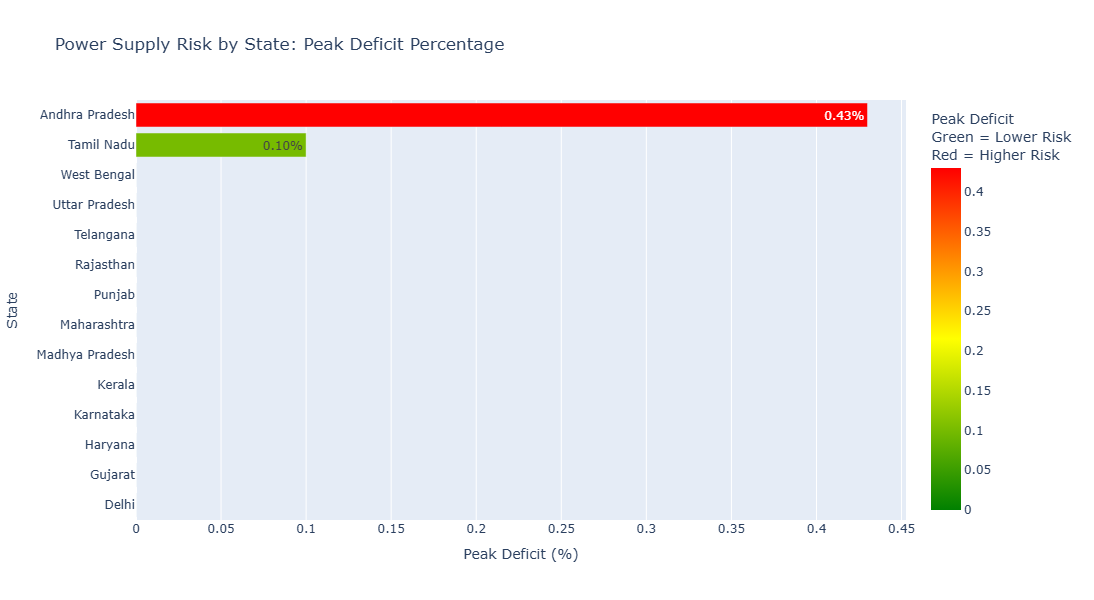

In [23]:
power_risk_plot = master_df.sort_values(
    "Peak_Deficit_Percentage",
    ascending=False
)

fig = px.bar(
    power_risk_plot,
    x="Peak_Deficit_Percentage",
    y="State",
    orientation="h",
    title="Power Supply Risk by State: Peak Deficit Percentage",
    labels={
        "Peak_Deficit_Percentage": "Peak Deficit (%)",
        "State": "State"
    },
    text="Peak_Deficit_Percentage",
    color="Peak_Deficit_Percentage",
    color_continuous_scale=[
        [0.0, "green"],
        [0.5, "yellow"],
        [1.0, "red"]
    ]
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=600,
    coloraxis_colorbar=dict(
        title="Peak Deficit<br>Green = Lower Risk<br>Red = Higher Risk"
    )
)

fig.show()

## Observation: Power Supply Risk

Only Andhra Pradesh and Tamil Nadu show a visible peak deficit, and even those values are below 0.5%. Most selected states show zero peak deficit in the latest available power data.

This means power deficit is not a strong differentiator across most states in the current dataset. Therefore, charging pressure and infrastructure gap are more important differentiating variables than power risk for this version of the analysis.

## 16. Charging Pressure vs Power Supply Risk

Since most selected states show little to no peak power deficit, power supply risk is not strongly differentiating across all states. Instead of using separate power deficit and power readiness charts, this final scatter plot combines charging infrastructure pressure with power supply risk.

The x-axis shows cumulative EVs per connector, which represents charging infrastructure pressure. The y-axis shows peak deficit percentage, which represents power supply risk. Bubble size represents cumulative EV registrations.

This chart helps identify whether states with high charging pressure also face electricity supply risk. States toward the right side have stronger charging infrastructure pressure, while states higher on the chart have higher power supply risk.


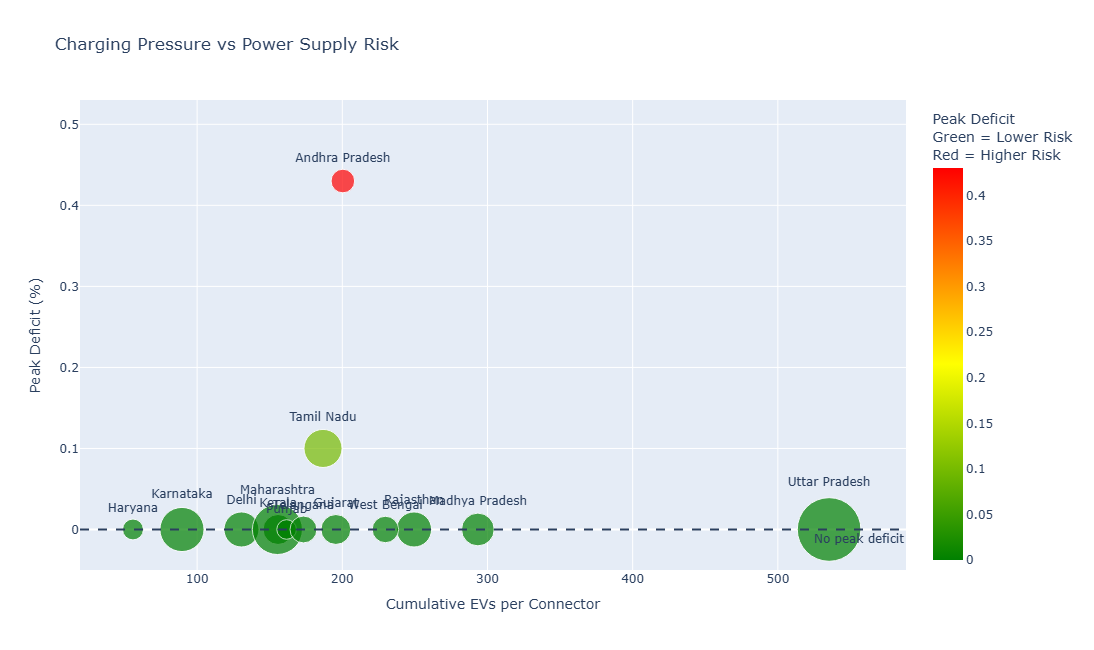

In [24]:
power_opportunity_plot = master_df.copy()

max_deficit = power_opportunity_plot["Peak_Deficit_Percentage"].max()

fig = px.scatter(
    power_opportunity_plot,
    x="Cumulative_EVs_per_Connector",
    y="Peak_Deficit_Percentage",
    size="Cumulative_EV_Registrations_2025_26",
    color="Peak_Deficit_Percentage",
    hover_name="State",
    text="State",
    title="Charging Pressure vs Power Supply Risk",
    labels={
        "Cumulative_EVs_per_Connector": "Cumulative EVs per Connector",
        "Peak_Deficit_Percentage": "Peak Deficit (%)",
        "Cumulative_EV_Registrations_2025_26": "Cumulative EV Registrations up to 2025–26"
    },
    size_max=45,
    color_continuous_scale=[
        [0.0, "green"],
        [0.5, "yellow"],
        [1.0, "red"]
    ]
)

fig.update_traces(
    textposition="top center"
)

fig.add_hline(
    y=0,
    line_dash="dash",
    annotation_text="No peak deficit",
    annotation_position="bottom right"
)

fig.update_yaxes(
    range=[-0.05, max(0.5, max_deficit + 0.1)]
)

fig.update_layout(
    height=650,
    coloraxis_colorbar=dict(
        title="Peak Deficit<br>Green = Lower Risk<br>Red = Higher Risk"
    )
)

fig.show()

## Observation: Charging Pressure vs Power Supply Risk

The combined power-risk scatter plot shows that Uttar Pradesh has the highest charging pressure but no peak deficit in the latest available power data. This suggests that its main issue is not immediate electricity deficit, but charging infrastructure availability.

Andhra Pradesh has moderate charging pressure but the highest peak deficit among selected states. Tamil Nadu also shows a small peak deficit along with moderate charging pressure.

Overall, power supply risk appears limited in this dataset, while charging pressure remains the stronger investment signal.

## 17. Correlation Analysis

A correlation heatmap is used to understand the relationships between key numeric variables in the dataset. This helps identify whether EV demand, charging infrastructure, economic strength, charging pressure, and power readiness move together or behave independently.

Correlation values range from -1 to +1. A positive correlation means that two variables generally increase together, while a negative correlation means that one variable tends to increase as the other decreases. Since correlation does not prove causation, the results are used only to understand directional relationships in the data.


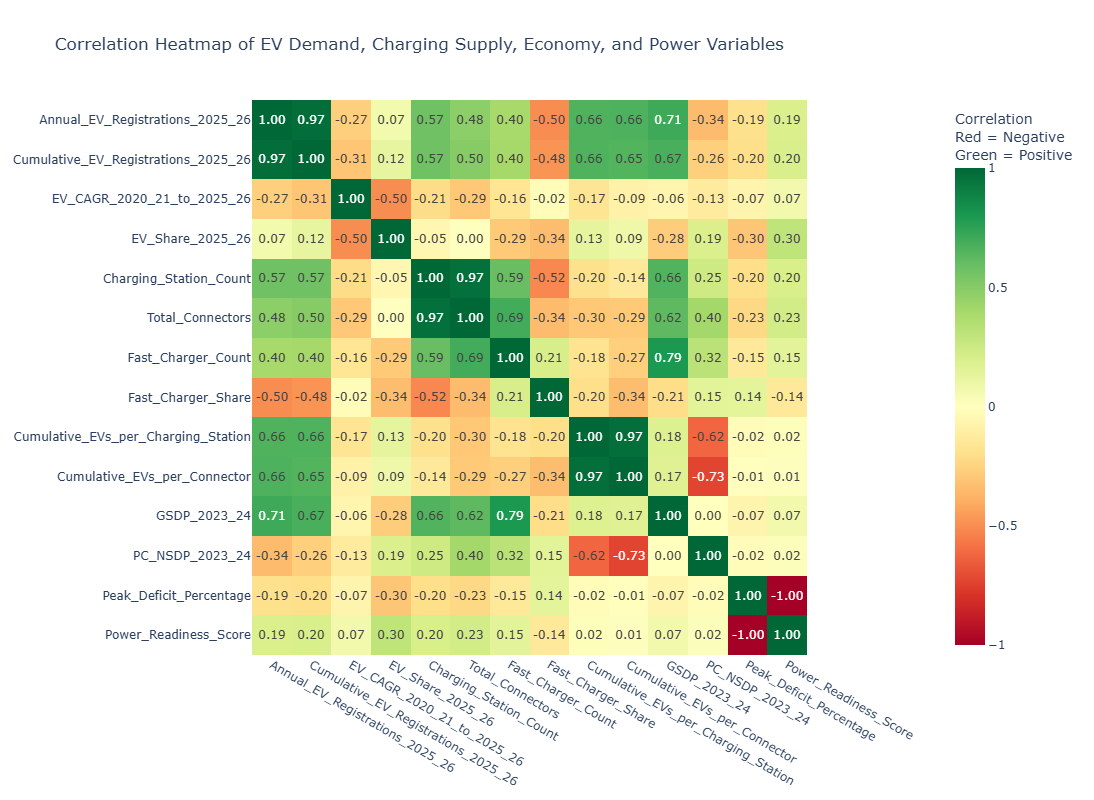

In [25]:
correlation_columns = [
    "Annual_EV_Registrations_2025_26",
    "Cumulative_EV_Registrations_2025_26",
    "EV_CAGR_2020_21_to_2025_26",
    "EV_Share_2025_26",

    "Charging_Station_Count",
    "Total_Connectors",
    "Fast_Charger_Count",
    "Fast_Charger_Share",

    "Cumulative_EVs_per_Charging_Station",
    "Cumulative_EVs_per_Connector",

    "GSDP_2023_24",
    "PC_NSDP_2023_24",

    "Peak_Deficit_Percentage",
    "Power_Readiness_Score"
]

corr_df = master_df[correlation_columns].corr()

fig = px.imshow(
    corr_df,
    text_auto=".2f",
    title="Correlation Heatmap of EV Demand, Charging Supply, Economy, and Power Variables",
    color_continuous_scale="RdYlGn",
    zmin=-1,
    zmax=1
)

fig.update_layout(
    height=800,
    width=1000,
    coloraxis_colorbar=dict(
        title="Correlation<br>Red = Negative<br>Green = Positive"
    )
)

fig.show()

## Observation: Correlation Analysis

The correlation heatmap shows a very strong positive relationship between annual EV registrations and cumulative EV registrations. This means states with large existing EV bases also tend to have strong current EV registration activity.

Charging station count and total connectors are also strongly correlated, which is expected because states with more charging stations generally have more connectors. This confirms that both variables measure charging infrastructure supply, although connectors provide a better measure of actual charging capacity.

GSDP shows a positive relationship with annual EV registrations, cumulative EV registrations, charging stations, total connectors, and fast charger count. This suggests that larger state economies tend to have stronger EV demand and more charging infrastructure.

Per-capita NSDP shows a negative relationship with cumulative EVs per connector and cumulative EVs per charging station. This may suggest that higher-income states are relatively better supplied with charging infrastructure compared to their EV base.

EV CAGR has a negative relationship with annual and cumulative EV registrations. This indicates that some smaller or emerging EV markets are growing faster from a lower base, while larger EV markets may show slower percentage growth.

Peak deficit percentage and power readiness score are perfectly negatively correlated because power readiness was derived from peak deficit. Therefore, both should not be treated as independent variables in later scoring or regression.


## 18. State-Level Comparison Table

After visual analysis, a state-level comparison table is created to summarize the most important EV demand, charging infrastructure, economic, and power readiness indicators.

This table helps compare states directly before building the final investment scoring model. It includes annual EV demand, cumulative EV market size, EV growth momentum, charging supply, charging pressure, economic strength, and power supply risk.


In [26]:
comparison_columns = [
    "State",
    "Annual_EV_Registrations_2025_26",
    "Cumulative_EV_Registrations_2025_26",
    "EV_CAGR_2020_21_to_2025_26",
    "EV_Share_2025_26",
    "Charging_Station_Count",
    "Total_Connectors",
    "Fast_Charger_Share",
    "Cumulative_EVs_per_Connector",
    "Cumulative_EVs_per_Charging_Station",
    "GSDP_2023_24",
    "PC_NSDP_2023_24",
    "Peak_Deficit_Percentage",
    "Power_Readiness_Score"
]

state_comparison = master_df[comparison_columns].copy()

state_comparison = state_comparison.sort_values(
    "Cumulative_EVs_per_Connector",
    ascending=False
)

In [27]:
state_comparison_display = state_comparison.rename(columns={
    "Annual_EV_Registrations_2025_26": "Annual EVs 2025-26",
    "Cumulative_EV_Registrations_2025_26": "Cumulative EVs",
    "EV_CAGR_2020_21_to_2025_26": "EV CAGR (%)",
    "EV_Share_2025_26": "EV Share (%)",
    "Charging_Station_Count": "Charging Stations",
    "Total_Connectors": "Connectors",
    "Fast_Charger_Share": "Fast Charger Share (%)",
    "Cumulative_EVs_per_Connector": "EVs per Connector",
    "Cumulative_EVs_per_Charging_Station": "EVs per Station",
    "GSDP_2023_24": "GSDP 2023-24",
    "PC_NSDP_2023_24": "PC NSDP 2023-24",
    "Peak_Deficit_Percentage": "Peak Deficit (%)",
    "Power_Readiness_Score": "Power Readiness"
})

state_comparison_display.reset_index(drop = True)

,State,Annual EVs 2025-26,Cumulative EVs,EV CAGR (%),EV Share (%),Charging Stations,Connectors,Fast Charger Share (%),EVs per Connector,EVs per Station,GSDP 2023-24,PC NSDP 2023-24,Peak Deficit (%),Power Readiness
0,Uttar Pradesh,414565.0,1584541.0,67.34,8.34,2328,2960,22.12,535.32,680.64,2.562792e+06,93422.085615,0.00,100.00
1,Madhya Pradesh,158886.0,420139.0,105.02,6.60,1147,1432,29.21,293.39,366.29,1.353809e+06,139712.786189,0.00,100.00
2,Rajasthan,123153.0,480865.0,71.90,5.54,1531,1928,33.51,249.41,314.09,1.521510e+06,166647.299904,0.00,100.00
3,West Bengal,133390.0,273789.0,74.67,8.86,903,1192,35.44,229.69,303.20,1.651374e+06,149515.178003,0.00,100.00
4,Andhra Pradesh,69495.0,218230.0,85.85,2.62,793,1089,42.88,200.39,275.20,1.422094e+06,237950.625141,0.43,99.57
5,Gujarat,86280.0,350476.0,119.66,2.31,1208,1792,47.52,195.58,290.13,2.425804e+06,297722.298614,0.00,100.00
6,Tamil Nadu,190823.0,567634.0,74.07,4.17,1781,3040,51.49,186.72,318.72,2.721571e+06,315219.594435,0.10,99.90
7,Telangana,88881.0,282402.0,102.40,4.29,1064,1630,45.49,173.25,265.42,1.464378e+06,346457.052217,0.00,100.00
8,Punjab,46136.0,150500.0,117.22,7.51,715,931,31.61,161.65,210.49,7.458195e+05,195030.509175,0.00,100.00
9,Kerala,115400.0,352288.0,120.84,4.07,1394,2262,34.94,155.74,252.72,1.139945e+06,279750.717944,0.00,100.00


The comparison table brings together the key indicators used in the EDA. States with high cumulative EV registrations, high EV growth, and high EVs per connector may indicate stronger charging infrastructure expansion opportunity. At the same time, economic strength and power readiness provide important context for investment feasibility and risk.


## 19. Feature Normalization for Investment Scoring

The dataset contains variables with different units and scales. For example, EV registrations are measured in counts, GSDP is measured in monetary value, EV share is measured in percentage, and charging gap is measured as EVs per connector or EVs per station.

To make these variables comparable, selected features are normalized into 0–100 scores. A higher score represents a stronger value for that specific investment factor.

For opportunity-based variables such as EV demand, EV growth, EV share, and charging gap, higher values are treated as stronger investment signals. For power readiness, higher values indicate lower power risk and better infrastructure readiness.


In [28]:
scoring_df = master_df.copy()

In [29]:
def min_max_score(series):
    min_value = series.min()
    max_value = series.max()
    
    if max_value == min_value:
        return series * 0 + 100
    
    return ((series - min_value) / (max_value - min_value)) * 100

### Demand and growth scores

In [30]:
scoring_df["Annual_EV_Demand_Score"] = min_max_score(
    scoring_df["Annual_EV_Registrations_2025_26"]
)

scoring_df["Cumulative_EV_Market_Score"] = min_max_score(
    scoring_df["Cumulative_EV_Registrations_2025_26"]
)

scoring_df["EV_Growth_Score"] = min_max_score(
    scoring_df["EV_CAGR_2020_21_to_2025_26"]
)

scoring_df["EV_Adoption_Intensity_Score"] = min_max_score(
    scoring_df["EV_Share_2025_26"]
)

### Charging gap scores

In [31]:
scoring_df["Connector_Gap_Score"] = min_max_score(
    scoring_df["Cumulative_EVs_per_Connector"]
)

scoring_df["Station_Gap_Score"] = min_max_score(
    scoring_df["Cumulative_EVs_per_Charging_Station"]
)

### Infrastructure and economy scores

In [32]:
scoring_df["Charging_Supply_Score"] = min_max_score(
    scoring_df["Total_Connectors"]
)

scoring_df["Fast_Charger_Quality_Score"] = min_max_score(
    scoring_df["Fast_Charger_Share"]
)

scoring_df["GSDP_Score"] = min_max_score(
    scoring_df["GSDP_2023_24"]
)

scoring_df["Per_Capita_Income_Score"] = min_max_score(
    scoring_df["PC_NSDP_2023_24"]
)

### Power readiness score

In [33]:
scoring_df["Power_Score"] = min_max_score(
    scoring_df["Power_Readiness_Score"]
)

### Rounding score columns

In [34]:
score_columns = [
    "Annual_EV_Demand_Score",
    "Cumulative_EV_Market_Score",
    "EV_Growth_Score",
    "EV_Adoption_Intensity_Score",
    "Connector_Gap_Score",
    "Station_Gap_Score",
    "Charging_Supply_Score",
    "Fast_Charger_Quality_Score",
    "GSDP_Score",
    "Per_Capita_Income_Score",
    "Power_Score"
]

scoring_df[score_columns] = scoring_df[score_columns].round(2)

### Score table

In [35]:
scoring_df[
    [
        "State",
        "Annual_EV_Demand_Score",
        "Cumulative_EV_Market_Score",
        "EV_Growth_Score",
        "EV_Adoption_Intensity_Score",
        "Connector_Gap_Score",
        "Station_Gap_Score",
        "GSDP_Score",
        "Per_Capita_Income_Score",
        "Power_Score"
    ]
].sort_values("Connector_Gap_Score", ascending=False)

,State,Annual_EV_Demand_Score,Cumulative_EV_Market_Score,EV_Growth_Score,EV_Adoption_Intensity_Score,Connector_Gap_Score,Station_Gap_Score,GSDP_Score,Per_Capita_Income_Score,Power_Score
12,Uttar Pradesh,100.00,100.00,18.02,39.31,100.00,100.00,54.89,0.00,100.00
6,Madhya Pradesh,32.26,18.80,75.76,27.97,49.55,43.52,18.37,12.65,100.00
9,Rajasthan,22.79,23.04,25.01,21.06,40.37,34.14,23.43,20.01,100.00
13,West Bengal,25.50,8.60,29.25,42.70,36.26,32.19,27.36,15.33,100.00
0,Andhra Pradesh,8.57,4.72,46.38,2.02,30.15,27.16,20.43,39.49,0.00
2,Gujarat,13.02,13.94,98.19,0.00,29.15,29.84,50.75,55.82,100.00
10,Tamil Nadu,40.72,29.09,28.33,12.13,27.30,34.98,59.69,60.60,76.74
11,Telangana,13.71,9.20,71.74,12.91,24.49,25.40,21.71,69.14,100.00
8,Punjab,2.38,0.00,94.45,33.90,22.07,15.53,0.00,27.76,100.00
5,Kerala,20.74,14.07,100.00,11.47,20.84,23.12,11.91,50.91,100.00


The selected variables were normalized into 0–100 scores so that different indicators could be compared on the same scale. These scores will be used to build the final EV charging investment score.

Demand-related scores capture current and cumulative EV market strength. Growth and adoption scores capture future market momentum. Charging gap scores capture underserved infrastructure conditions. Economic and power scores provide context for investment feasibility and risk.


## 20. Final EV Charging Investment Opportunity Score

After normalizing the main variables, a weighted investment opportunity score is created to rank states based on overall EV charging infrastructure potential.

The score combines EV demand, cumulative EV market size, EV growth momentum, EV adoption intensity, charging infrastructure gap, economic strength, charging quality, and power readiness.

Higher scores indicate stronger investment opportunity. In this model, charging gap is treated as an opportunity signal because states with higher EVs per connector or higher EVs per charging station may require faster charging infrastructure expansion.


In [36]:
scoring_df["Investment_Opportunity_Score"] = (
    scoring_df["Annual_EV_Demand_Score"] * 0.15 +
    scoring_df["Cumulative_EV_Market_Score"] * 0.20 +
    scoring_df["EV_Growth_Score"] * 0.15 +
    scoring_df["EV_Adoption_Intensity_Score"] * 0.10 +
    scoring_df["Connector_Gap_Score"] * 0.20 +
    scoring_df["Station_Gap_Score"] * 0.10 +
    scoring_df["GSDP_Score"] * 0.05 +
    scoring_df["Fast_Charger_Quality_Score"] * 0.03 +
    scoring_df["Power_Score"] * 0.02
)

scoring_df["Investment_Opportunity_Score"] = (
    scoring_df["Investment_Opportunity_Score"].round(2)
)

In [37]:
investment_ranking = scoring_df[
    [
        "State",
        "Investment_Opportunity_Score",
        "Annual_EV_Demand_Score",
        "Cumulative_EV_Market_Score",
        "EV_Growth_Score",
        "EV_Adoption_Intensity_Score",
        "Connector_Gap_Score",
        "Station_Gap_Score",
        "GSDP_Score",
        "Fast_Charger_Quality_Score",
        "Power_Score"
    ]
].sort_values(
    "Investment_Opportunity_Score",
    ascending=False
)

investment_ranking

,State,Investment_Opportunity_Score,Annual_EV_Demand_Score,Cumulative_EV_Market_Score,EV_Growth_Score,EV_Adoption_Intensity_Score,Connector_Gap_Score,Station_Gap_Score,GSDP_Score,Fast_Charger_Quality_Score,Power_Score
12,Uttar Pradesh,76.77,100.00,100.00,18.02,39.31,100.00,100.00,54.89,13.19,100.00
7,Maharashtra,46.49,64.08,57.90,63.52,19.36,20.75,19.84,100.00,23.37,100.00
6,Madhya Pradesh,40.62,32.26,18.80,75.76,27.97,49.55,43.52,18.37,22.79,100.00
2,Gujarat,34.25,13.02,13.94,98.19,0.00,29.15,29.84,50.75,47.59,100.00
10,Tamil Nadu,32.45,40.72,29.09,28.33,12.13,27.30,34.98,59.69,52.97,76.74
5,Kerala,32.06,20.74,14.07,100.00,11.47,20.84,23.12,11.91,30.55,100.00
9,Rajasthan,29.40,22.79,23.04,25.01,21.06,40.37,34.14,23.43,28.62,100.00
13,West Bengal,28.98,25.50,8.60,29.25,42.70,36.26,32.19,27.36,31.23,100.00
4,Karnataka,27.85,48.83,42.67,31.81,10.76,7.04,0.00,54.73,0.00,100.00
11,Telangana,27.82,13.71,9.20,71.74,12.91,24.49,25.40,21.71,44.84,100.00


## 21. Investment Opportunity Score Ranking

The normalized scores are combined into a final Investment Opportunity Score to rank states based on EV charging infrastructure potential. This score considers EV demand, cumulative EV market size, EV growth momentum, EV adoption intensity, charging infrastructure pressure, economic strength, fast charger quality, and power readiness.

Before creating investment categories, the score is visualized as a ranked bar chart. This helps understand how states compare with each other and whether there are clear groups such as high opportunity, moderate opportunity, and lower priority states.


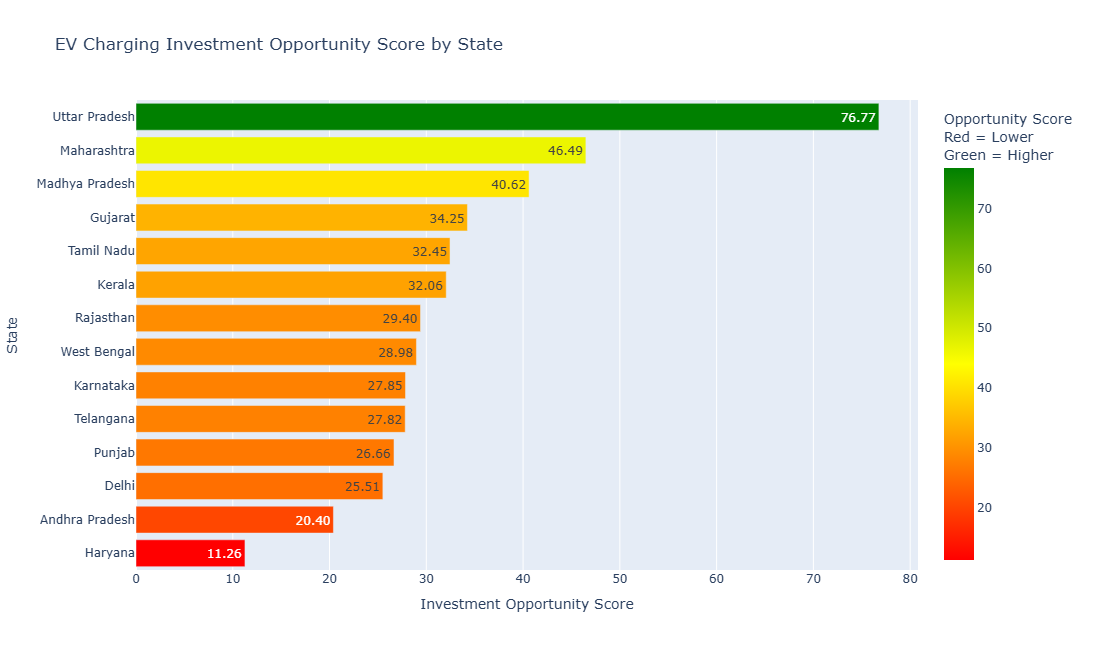

In [38]:
investment_score_plot = scoring_df.sort_values(
    "Investment_Opportunity_Score",
    ascending=False
)

fig = px.bar(
    investment_score_plot,
    x="Investment_Opportunity_Score",
    y="State",
    orientation="h",
    title="EV Charging Investment Opportunity Score by State",
    labels={
        "Investment_Opportunity_Score": "Investment Opportunity Score",
        "State": "State"
    },
    text="Investment_Opportunity_Score",
    color="Investment_Opportunity_Score",
    color_continuous_scale=[
        [0.0, "red"],
        [0.5, "yellow"],
        [1.0, "green"]
    ]
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=650,
    coloraxis_colorbar=dict(
        title="Opportunity Score<br>Red = Lower<br>Green = Higher"
    )
)

fig.show()

## 22. Investment Opportunity Categories

After calculating the Investment Opportunity Score, states are grouped into opportunity categories. Categorization makes the final result easier to interpret and helps convert numerical scores into actionable investment segments.

Since the analysis includes only 14 selected states/UTs, percentile-based categories are used instead of fixed score thresholds. This allows states to be compared relative to each other within the selected sample.


In [39]:
score_col = "Investment_Opportunity_Score"

high_threshold = scoring_df[score_col].quantile(0.75)
moderate_threshold = scoring_df[score_col].quantile(0.40)

def assign_opportunity_category(score):
    if score >= high_threshold:
        return "High Opportunity"
    elif score >= moderate_threshold:
        return "Moderate Opportunity"
    else:
        return "Lower Priority"

scoring_df["Opportunity_Category"] = scoring_df[score_col].apply(
    assign_opportunity_category
)

In [40]:
category_table = scoring_df[
    [
        "State",
        "Investment_Opportunity_Score",
        "Opportunity_Category"
    ]
].sort_values(
    "Investment_Opportunity_Score",
    ascending=False
)

category_table

,State,Investment_Opportunity_Score,Opportunity_Category
12,Uttar Pradesh,76.77,High Opportunity
7,Maharashtra,46.49,High Opportunity
6,Madhya Pradesh,40.62,High Opportunity
2,Gujarat,34.25,High Opportunity
10,Tamil Nadu,32.45,Moderate Opportunity
5,Kerala,32.06,Moderate Opportunity
9,Rajasthan,29.40,Moderate Opportunity
13,West Bengal,28.98,Moderate Opportunity
4,Karnataka,27.85,Lower Priority
11,Telangana,27.82,Lower Priority


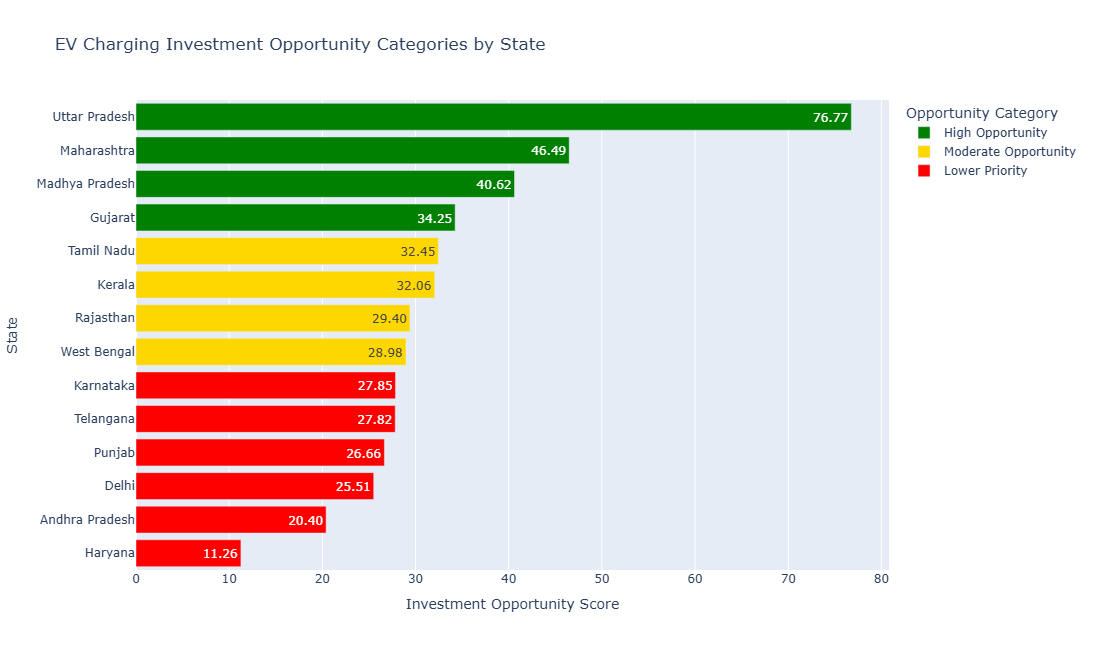

In [41]:
category_order = [
    "High Opportunity",
    "Moderate Opportunity",
    "Lower Priority"
]

color_map = {
    "High Opportunity": "green",
    "Moderate Opportunity": "gold",
    "Lower Priority": "red"
}

fig = px.bar(
    category_table,
    x="Investment_Opportunity_Score",
    y="State",
    orientation="h",
    color="Opportunity_Category",
    category_orders={
        "Opportunity_Category": category_order
    },
    color_discrete_map=color_map,
    title="EV Charging Investment Opportunity Categories by State",
    labels={
        "Investment_Opportunity_Score": "Investment Opportunity Score",
        "State": "State",
        "Opportunity_Category": "Opportunity Category"
    },
    text="Investment_Opportunity_Score"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="inside"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=650
)

fig.show()

The categorized ranking converts the final investment score into clear opportunity groups. High Opportunity states represent the strongest candidates for EV charging infrastructure expansion within the selected sample. Moderate Opportunity states show good potential but may require more selective investment decisions. Lower Priority states are comparatively less attractive based on the current scoring model.

These categories are relative to the 14 selected states/UTs and should be interpreted as a decision-support framework rather than a fixed national ranking.


### Observation: Investment Opportunity Score Ranking

Uttar Pradesh ranks as the strongest EV charging investment opportunity among the selected states, with a much higher score than the rest of the sample. This is mainly driven by its large annual EV registrations, largest cumulative EV base, and very high charging pressure per connector and per charging station.

Maharashtra, Madhya Pradesh, and Gujarat also fall into the High Opportunity category. Maharashtra combines strong EV demand, large economic strength, and a sizeable EV base, while Madhya Pradesh and Gujarat show stronger expansion potential due to growth momentum and charging gap indicators.

Tamil Nadu, Kerala, Rajasthan, and West Bengal fall into the Moderate Opportunity category. These states show meaningful EV demand or growth, but their overall investment opportunity is lower than the high-opportunity group based on the combined score.

Karnataka, Delhi, Telangana, Punjab, Andhra Pradesh, and Haryana fall into the Lower Priority category in this scoring model. This does not mean these states are weak EV markets. For example, Karnataka has strong charging infrastructure and Delhi has high EV adoption intensity, but their lower scores indicate that they may be relatively better supplied or less underserved compared to states with higher charging pressure.

Overall, the score should be interpreted as an EV charging expansion opportunity score, not simply a ranking of the most developed EV markets.


## 23. Final Scored Dataset

After calculating the Investment Opportunity Score and assigning opportunity categories, the final scored dataset is saved for future use.

This dataset will be used for final reporting, dashboard development, PCA analysis, regression analysis, and recommendation building. It contains the cleaned state-level variables, normalized scoring features, final investment score, and investment opportunity category.


In [42]:
scoring_df.to_csv(
    "../data/cleaned/final_ev_charging_investment_scored_dataset.csv",
    index=False
)

In [43]:
final_scored_df = pd.read_csv(
    "../data/cleaned/final_ev_charging_investment_scored_dataset.csv"
)

final_scored_df.head()

,State,Latest_EV_Year,Annual_EV_Registrations_2025_26,Cumulative_EV_Registrations_2025_26,EV_CAGR_2020_21_to_2025_26,EV_Share_2025_26,Charging_Station_Count,Total_Connectors,Fast_Charger_Count,Avg_Charger_Rating,District_Count,City_Count,Private_Charger_Rows,Govt_Charger_Rows,Connectors_per_Station,Fast_Charger_Share,Cumulative_EVs_per_Charging_Station,Cumulative_EVs_per_Connector,Annual_EVs_2025_26_per_Charging_Station,Annual_EVs_2025_26_per_Connector,GSDP_2023_24,PC_NSDP_2023_24,Period,Date,Peak_Demand,Peak_Met,Peak_Deficit,Peak_Deficit_Percentage,Power_Readiness_Score,Annual_EV_Demand_Score,Cumulative_EV_Market_Score,EV_Growth_Score,EV_Adoption_Intensity_Score,Connector_Gap_Score,Station_Gap_Score,Charging_Supply_Score,Fast_Charger_Quality_Score,GSDP_Score,Per_Capita_Income_Score,Power_Score,Investment_Opportunity_Score,Opportunity_Category
0,Andhra Pradesh,2025-26,69495.0,218230.0,85.85,2.62,793,1089,340,23.229664,46,385,161,702,1.37,42.88,275.20,200.39,87.64,63.82,1.422094e+06,237950.625141,Dec-2025,2025-12-01,11636.0,11586.0,50.0,0.43,99.57,8.57,4.72,46.38,2.02,30.15,27.16,2.08,41.31,20.43,39.49,0.0,20.40,Lower Priority
1,Delhi,2025-26,107644.0,480158.0,55.58,17.65,1977,3678,395,11.808317,24,3,2784,691,1.86,19.98,242.87,130.55,54.45,29.27,1.112905e+06,459408.489922,Dec-2025,2025-12-01,5505.0,5505.0,0.0,0.00,100.00,18.68,22.99,0.00,100.00,15.58,21.35,36.24,10.29,11.09,100.00,100.0,25.51,Lower Priority
2,Gujarat,2025-26,86280.0,350476.0,119.66,2.31,1208,1792,574,26.449754,60,291,307,1116,1.48,47.52,290.13,195.58,71.42,48.15,2.425804e+06,297722.298614,Dec-2025,2025-12-01,24369.0,24369.0,0.0,0.00,100.00,13.02,13.94,98.19,0.00,29.15,29.84,11.36,47.59,50.75,55.82,100.0,34.25,High Opportunity
3,Haryana,2025-26,37137.0,170520.0,65.08,5.75,936,3055,807,15.968648,39,173,2013,864,3.26,86.22,182.18,55.82,39.68,12.16,1.085510e+06,319363.013877,Dec-2025,2025-12-01,9512.0,9512.0,0.0,0.00,100.00,0.00,1.40,14.56,22.43,0.00,10.44,28.02,100.00,10.26,61.73,100.0,11.26,Lower Priority
4,Karnataka,2025-26,221441.0,762386.0,76.34,3.96,6146,8512,761,8.630936,46,505,6288,1958,1.38,12.38,124.05,89.57,36.03,26.02,2.557241e+06,339813.428685,Dec-2025,2025-12-01,17220.0,17220.0,0.0,0.00,100.00,48.83,42.67,31.81,10.76,7.04,0.00,100.00,0.00,54.73,67.32,100.0,27.85,Lower Priority


In [44]:
final_scored_df[
    [
        "State",
        "Investment_Opportunity_Score",
        "Opportunity_Category"
    ]
].sort_values(
    "Investment_Opportunity_Score",
    ascending=False
)

,State,Investment_Opportunity_Score,Opportunity_Category
12,Uttar Pradesh,76.77,High Opportunity
7,Maharashtra,46.49,High Opportunity
6,Madhya Pradesh,40.62,High Opportunity
2,Gujarat,34.25,High Opportunity
10,Tamil Nadu,32.45,Moderate Opportunity
5,Kerala,32.06,Moderate Opportunity
9,Rajasthan,29.40,Moderate Opportunity
13,West Bengal,28.98,Moderate Opportunity
4,Karnataka,27.85,Lower Priority
11,Telangana,27.82,Lower Priority


The scoring model prioritizes underserved demand-supply gaps. Therefore, states with strong existing infrastructure may rank lower even if they are mature EV markets.

## 24. PCA Analysis for State Clustering

Principal Component Analysis is used to reduce multiple investment-related variables into two main components. This helps visualize how states group together based on EV demand, EV growth, charging infrastructure gap, economic strength, and infrastructure readiness.

The purpose of PCA is not to create the final ranking, but to understand whether states with similar EV charging investment characteristics form natural clusters. This can help identify mature EV markets, high-gap opportunity markets, and lower-priority markets.


In [45]:
pca_df = final_scored_df.copy()

In [46]:
pca_features = [
    "Annual_EV_Demand_Score",
    "Cumulative_EV_Market_Score",
    "EV_Growth_Score",
    "EV_Adoption_Intensity_Score",
    "Connector_Gap_Score",
    "Charging_Supply_Score",
    "Fast_Charger_Quality_Score",
    "GSDP_Score",
    "Per_Capita_Income_Score",
    "Power_Score"
]

In [47]:
missing_cols = [col for col in pca_features if col not in pca_df.columns]

missing_cols

[]

In [48]:
X = pca_df[pca_features].copy()

X_scaled = (X - X.mean()) / X.std(ddof=0)

In [49]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)

pca_components = U[:, :2] * S[:2]

pca_df["PC1"] = pca_components[:, 0]
pca_df["PC2"] = pca_components[:, 1]

In [50]:
explained_variance = (S ** 2) / (len(X_scaled) - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

print(f"PC1 explains {explained_variance_ratio[0] * 100:.2f}% of variance")
print(f"PC2 explains {explained_variance_ratio[1] * 100:.2f}% of variance")
print(f"Total variance explained: {(explained_variance_ratio[0] + explained_variance_ratio[1]) * 100:.2f}%")

PC1 explains 37.16% of variance
PC2 explains 21.04% of variance
Total variance explained: 58.20%


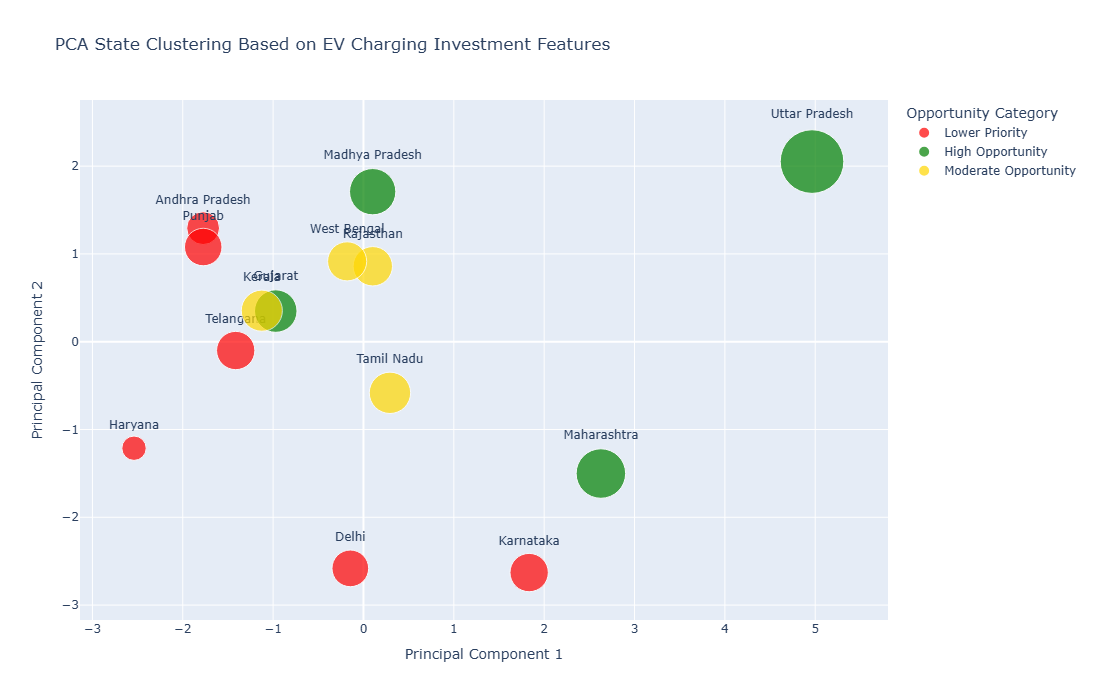

In [51]:
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Opportunity_Category",
    size="Investment_Opportunity_Score",
    hover_name="State",
    text="State",
    title="PCA State Clustering Based on EV Charging Investment Features",
    labels={
        "PC1": "Principal Component 1",
        "PC2": "Principal Component 2",
        "Opportunity_Category": "Opportunity Category",
        "Investment_Opportunity_Score": "Investment Opportunity Score"
    },
    color_discrete_map={
        "High Opportunity": "green",
        "Moderate Opportunity": "gold",
        "Lower Priority": "red"
    },
    size_max=45
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    height=700
)

fig.show()

### Observation: PCA State Clustering

The first two principal components explain 58.20% of the total variance in the scoring features. This means the PCA plot captures a meaningful portion of the differences between states, although some information is still spread across other components.

Uttar Pradesh appears clearly separated from the other states, showing that its EV charging investment profile is very different. This is mainly because it has the largest EV base, highest annual EV registrations, and the strongest charging pressure.

Maharashtra also appears as a high-opportunity state, but it is positioned away from Uttar Pradesh. This suggests that Maharashtra’s opportunity profile is different: it has strong EV demand and economic strength, but relatively better infrastructure compared to Uttar Pradesh.

Madhya Pradesh and Gujarat appear closer to the middle-high opportunity region, indicating expansion potential driven by growth and charging gap factors. Moderate-opportunity states such as Rajasthan, West Bengal, Tamil Nadu, and Kerala form a middle group.

Some mature or better-supplied EV markets such as Karnataka and Delhi appear in the lower-priority region in this scoring model. This does not mean they are weak EV markets. Instead, it means they may be relatively better supplied or less underserved compared to states with stronger charging pressure.

Overall, the PCA plot supports the scoring model by showing that high-opportunity states are not randomly assigned. They have distinct investment profiles compared to moderate and lower-priority states.


In [52]:
pca_loadings = pd.DataFrame(
    Vt[:2].T,
    index=pca_features,
    columns=["PC1_Loading", "PC2_Loading"]
)
pca_loadings.sort_values("PC2_Loading", ascending=False)

,PC1_Loading,PC2_Loading
Connector_Gap_Score,0.330257,0.489329
EV_Growth_Score,-0.158654,0.236063
Annual_EV_Demand_Score,0.509207,0.040169
Fast_Charger_Quality_Score,-0.311475,0.014244
Cumulative_EV_Market_Score,0.503804,0.003718
Power_Score,0.126211,-0.151315
EV_Adoption_Intensity_Score,0.079925,-0.172288
GSDP_Score,0.363075,-0.174324
Charging_Supply_Score,0.272992,-0.522462
Per_Capita_Income_Score,-0.164218,-0.589123


### PCA Component Interpretation

The PCA loading table helps explain what the two principal components represent.

PC1 has strong positive loadings for Annual EV Demand Score, Cumulative EV Market Score, GSDP Score, Connector Gap Score, and Charging Supply Score. This suggests that PC1 mainly represents overall EV market scale and investment relevance. States with higher PC1 values generally have larger EV markets, stronger current EV demand, larger economies, and more visible charging infrastructure pressure.

PC2 has a strong positive loading for Connector Gap Score and EV Growth Score, while it has negative loadings for Charging Supply Score and Per-Capita Income Score. This suggests that PC2 separates underserved growth markets from better-supplied or higher-income markets. States with higher PC2 values may have stronger charging pressure and growth momentum, while states with lower PC2 values may have better charging supply or higher income levels.

In this PCA, Uttar Pradesh appears far from most other states because it has extremely high EV demand, cumulative EV base, and charging pressure. Maharashtra is also separated but in a different direction, reflecting its strong market size and economic strength. States like Karnataka and Delhi appear lower in the PCA space because they are more mature or better supplied relative to their charging gap in this scoring model.

Overall, PCA supports the investment scoring results by showing that high-opportunity states have distinct feature patterns rather than being randomly ranked.


Note: The direction of PCA axes can be positive or negative depending on the mathematical decomposition, so the interpretation focuses on the relative loading patterns and state positions rather than the absolute sign of each axis.


In [53]:
reg_df = final_scored_df.copy()

In [54]:
target_col = "Annual_EV_Registrations_2025_26"

feature_cols = [
    "GSDP_2023_24",
    "PC_NSDP_2023_24",
    "Total_Connectors",
    "EV_Share_2025_26",
    "Power_Readiness_Score"
]

In [55]:
X = reg_df[feature_cols].copy()
y = reg_df[target_col].copy()

In [56]:
X_scaled = (X - X.mean()) / X.std(ddof=0)
y_scaled = (y - y.mean()) / y.std(ddof=0)

In [57]:
X_matrix = np.column_stack([
    np.ones(len(X_scaled)),
    X_scaled.values
])

In [58]:
coefficients = np.linalg.lstsq(
    X_matrix,
    y_scaled.values,
    rcond=None
)[0]

In [59]:
regression_results = pd.DataFrame({
    "Feature": ["Intercept"] + feature_cols,
    "Coefficient": coefficients
})

regression_results["Coefficient"] = regression_results["Coefficient"].round(3)

regression_results

,Feature,Coefficient
0,Intercept,-0.000
1,GSDP_2023_24,0.596
2,PC_NSDP_2023_24,-0.543
3,Total_Connectors,0.334
4,EV_Share_2025_26,0.337
5,Power_Readiness_Score,-0.016


### Regression Coefficient Interpretation

The regression coefficient table shows the directional relationship between selected factors and annual EV registrations in 2025–26.

GSDP has the strongest positive coefficient at 0.596, suggesting that states with larger economies tend to have higher annual EV registrations. This supports the idea that overall economic scale and market size are important drivers of EV adoption.

Total connectors also has a positive coefficient of 0.334, indicating that states with stronger charging connector availability are generally associated with higher annual EV registrations. This suggests that charging infrastructure availability may support EV adoption.

EV share has a positive coefficient of 0.337, showing that states with higher EV penetration in total vehicle registrations also tend to have higher annual EV registrations.

Per-capita NSDP has a negative coefficient of -0.543. This does not necessarily mean that higher income reduces EV adoption. Instead, it may reflect the small sample size and overlap between variables. For example, some states with lower per-capita income, such as Uttar Pradesh, have very high EV registrations because of their large population and vehicle market size. Therefore, total market scale appears more important than per-capita income in this model.

Power readiness has a very small negative coefficient of -0.016, suggesting that power readiness does not strongly explain annual EV registrations in this dataset. This is expected because most selected states showed little to no peak power deficit.

Overall, the regression supports the EDA finding that annual EV registrations are more strongly associated with overall economic scale, charging connector availability, and EV adoption intensity than with power readiness.


In [60]:
y_pred = X_matrix @ coefficients

ss_res = np.sum((y_scaled.values - y_pred) ** 2)
ss_total = np.sum((y_scaled.values - y_scaled.mean()) ** 2)

r_squared = 1 - (ss_res / ss_total)

print(f"R-squared: {r_squared:.3f}")

R-squared: 0.788


In [61]:
reg_df["Predicted_Annual_EV_Registrations_Scaled"] = y_pred
reg_df["Actual_Annual_EV_Registrations_Scaled"] = y_scaled.values

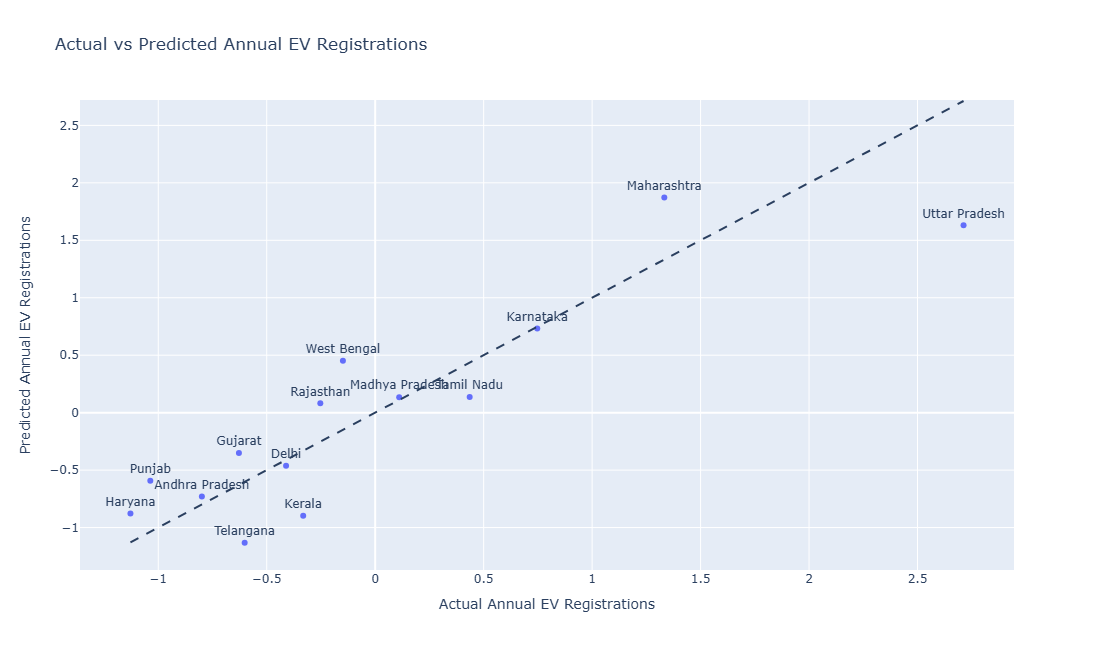

In [62]:
fig = px.scatter(
    reg_df,
    x="Actual_Annual_EV_Registrations_Scaled",
    y="Predicted_Annual_EV_Registrations_Scaled",
    hover_name="State",
    text="State",
    title="Actual vs Predicted Annual EV Registrations",
    labels={
        "Actual_Annual_EV_Registrations_Scaled": "Actual Annual EV Registrations",
        "Predicted_Annual_EV_Registrations_Scaled": "Predicted Annual EV Registrations"
    }
)

fig.add_shape(
    type="line",
    x0=reg_df["Actual_Annual_EV_Registrations_Scaled"].min(),
    y0=reg_df["Actual_Annual_EV_Registrations_Scaled"].min(),
    x1=reg_df["Actual_Annual_EV_Registrations_Scaled"].max(),
    y1=reg_df["Actual_Annual_EV_Registrations_Scaled"].max(),
    line=dict(dash="dash")
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    height=650
)

fig.show()

### Observation: Exploratory Regression Analysis

The exploratory regression model produced an R-squared value of 0.788, meaning that the selected explanatory variables explain around 78.8% of the variation in annual EV registrations across the selected states.

The actual vs predicted plot shows that many states are positioned close to the diagonal line, indicating that the model captures the broad pattern of EV registrations reasonably well. However, some states deviate from the line. Uttar Pradesh appears to be underpredicted, suggesting that its annual EV registrations are higher than what the selected variables alone would explain. Maharashtra appears relatively overpredicted, likely because its strong economic and infrastructure indicators increase the model’s predicted value.

Since the dataset contains only 14 states/UTs, this regression should not be treated as a high-accuracy predictive model. Instead, it is used as supporting analysis to understand directional relationships between EV registrations and factors such as economic strength, charging infrastructure, EV adoption intensity, and power readiness.


## 27. Conclusion

This project analyzed EV charging infrastructure investment potential across 14 selected Indian states/UTs by combining EV demand, EV growth, charging infrastructure, economic strength, and power readiness indicators.

The analysis shows that EV charging investment opportunity is not only determined by the number of EVs in a state. A strong opportunity appears when high EV demand is combined with limited charging supply, strong growth momentum, and reasonable economic or power readiness conditions.

Uttar Pradesh emerged as the strongest EV charging expansion opportunity. It had the highest annual EV registrations, the largest cumulative EV base, and the highest charging pressure per connector and per charging station. This suggests that EV adoption in Uttar Pradesh may be growing faster than public charging infrastructure availability.

Maharashtra also showed strong investment potential due to its large EV market, strong annual EV demand, and high economic strength. Madhya Pradesh and Gujarat appeared as attractive expansion opportunities because of their growth momentum and charging gap indicators.

Karnataka and Delhi are important EV markets, but they ranked lower in the opportunity score because this model prioritizes underserved charging gaps. Karnataka already has strong charging station and connector supply, while Delhi has high EV adoption intensity but comparatively lower expansion pressure in this scoring framework.

The PCA analysis supported the scoring results by showing that high-opportunity states have distinct investment profiles. Regression analysis further suggested that annual EV registrations are directionally associated with economic scale, charging connector availability, and EV adoption intensity.

Overall, the project identifies Uttar Pradesh, Maharashtra, Madhya Pradesh, and Gujarat as priority states for EV charging infrastructure expansion within the selected sample. The results should be interpreted as a decision-support framework rather than a fixed national ranking.


## Key Conclusion

The analysis found that Uttar Pradesh is the strongest EV charging infrastructure expansion opportunity among the selected states because it combines the largest EV market size with the highest charging pressure. Maharashtra, Madhya Pradesh, and Gujarat also show strong investment potential.

The project shows that mature EV markets are not always the highest expansion opportunities. States with high EV adoption but limited charging supply may offer stronger infrastructure investment potential than states that are already better supplied.


## 28. Limitations

This analysis has some important limitations.

First, the charging station dataset is a current infrastructure snapshot and does not provide historical charging station growth. Because of this, the project compares current charging infrastructure with historical EV adoption and cumulative EV registrations.

Second, cumulative EV registrations were created using the available year-wise EV registration data. This gives a useful estimate of EV market size, but it may not perfectly represent the exact number of EVs currently active on the road.

Third, the analysis focuses on 14 selected states/UTs instead of all Indian states and Union Territories. The results should therefore be interpreted within the selected sample and not as a complete national ranking.

Fourth, the investment score is based on selected variables and manually assigned weights. Although the weights are logically designed around EV demand, charging gap, growth, economy, and power readiness, different weighting choices may produce slightly different rankings.

Fifth, the regression analysis is exploratory because the dataset contains only 14 observations. Therefore, regression results should be used to understand directional relationships rather than make strong causal or predictive claims.

Finally, some useful factors such as road/highway density, land cost, city-level charging demand, charger utilization, electricity tariff, renewable energy availability, and policy incentives were not included in this version due to data availability and scope limitations.


## 29. Future Scope

This project can be improved in several ways.

Future versions can expand the analysis to include all Indian states and Union Territories. This would make the investment ranking more comprehensive and nationally representative.

Historical charging station data can also be added if available. This would allow comparison between EV growth and charging infrastructure growth over time.

The analysis can be improved by including city-level EV registrations and charging station data. City-level analysis would be more useful for actual charger placement decisions because EV charging demand is often concentrated in urban and highway locations.

Additional variables such as road density, highway network, land cost, electricity tariffs, renewable energy share, DISCOM reliability, state EV policies, and charger utilization can also be added to improve the investment model.

The scoring model can be further improved by testing multiple weighting scenarios or using optimization techniques to allocate a fixed investment budget across states.

Finally, the project can be converted into an interactive Streamlit dashboard where users can compare states, adjust weights, filter opportunity categories, and explore EV charging investment potential dynamically.


## Final Note

The project provides a data-driven framework for identifying EV charging infrastructure expansion opportunities across selected Indian states/UTs. The results are intended to support investment prioritization and strategic decision-making, while recognizing that final investment decisions should also consider local policy, land availability, electricity tariffs, charger utilization, and city-level demand patterns.
